# Unidad 3 - Análisis exploratorio de datos: medidas de resumen

## Introducción

Una de las primeras etapas en cualquier trabajo con datos es el **análisis exploratorio de datos** (EDA, por sus siglas en inglés). Antes de calcular indicadores, ajustar modelos o responder preguntas específicas, necesitamos entender con qué información estamos trabajando.

Con frecuencia, cuando el objetivo del análisis ya está definido —por ejemplo, estimar un promedio o construir un modelo predictivo—, tendemos a ir directamente al procedimiento técnico. Sin embargo, detenernos previamente a explorar los datos es fundamental para evitar errores y para interpretar correctamente los resultados.

El análisis exploratorio nos permite:

- Comprender la estructura del dataset.

- Detectar errores, valores faltantes o inconsistencias.

- Identificar patrones preliminares.

- Formular hipótesis.

- Elegir métodos adecuados para el análisis posterior.

En esta unidad estudiaremos medidas de resumen, es decir, herramientas numéricas que permiten describir y sintetizar la información contenida en los datos mediante ciertos valores representativos. Estas medidas constituyen una primera aproximación cuantitativa al conjunto de datos. En la próxima unidad complementaremos este enfoque mediante el uso de visualizaciones, que nos permitirán analizar la información desde una perspectiva gráfica.

Para trabajar los conceptos utilizaremos datos de la Encuesta Nacional de Factores de Riesgo (ENFR 2018, los datos pueden descargarse [acá](https://www.indec.gob.ar/indec/web/Institucional-Indec-BasesDeDatos-2)), una encuesta que releva información sobre condiciones de salud, hábitos y factores de riesgo en la población adulta argentina.

In [1]:
import pandas as pd

data = pd.read_csv('datasets/enfr2018.txt', delimiter = '|')

data.head()

,id,cod_provincia,region,tamanio_aglomerado,aglomerado,localidades_150,submuestra,bhcv01,bhcv02,bhcv03,...,glucemia_elevada,prevalencia_glucemia_elevada_combinada,findrisc,bimq06,bimq06_01,colesterol_elevado,prevalencia_colesterol_combinada,wf1p,wf2p,wf3p
0,1128639,2,1,1,1,1,1,3,2,1,...,NaN,NaN,2.0,NaN,NaN,NaN,NaN,2378,4464,0
1,1709939,2,1,1,1,1,0,1,4,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3588,0,0
2,6874130,2,1,1,1,1,0,3,2,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2740,0,0
3,10319375,2,1,1,1,1,1,3,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,493,0,0
4,11140857,2,1,1,1,1,0,3,3,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016,0,0


## Algunos conceptos fundamentales

Antes de avanzar con las medidas de resumen, es importante repasar algunos conceptos básicos de estadística.

### Población

En estadística, la población es el conjunto total de individuos, objetos, eventos o mediciones que comparten una característica de interés y sobre los cuales deseamos obtener información.

La población no necesariamente está compuesta por personas: puede estar formada por empresas, países, mediciones ambientales, transacciones financieras, experimentos de laboratorio, entre otros.

Un punto importante es que la población está definida por el objetivo del estudio. Por ejemplo:

- Si queremos estudiar el nivel de actividad física en Argentina, la población podría ser *“todas las personas adultas residentes en Argentina”*.

- Si queremos estudiar el rendimiento académico en una materia, la población podría ser *“todos los estudiantes que cursaron la materia en 2025”*.

La población puede ser muy grande (millones de individuos) o relativamente pequeña (unas pocas decenas).

### Muestra

En la práctica, rara vez es posible estudiar a toda la población. Por eso se selecciona una muestra, es decir, un subconjunto de la población que se utiliza para obtener información e inferir conclusiones sobre el conjunto total. El procedimiento mediante el cual se selecciona una muestra se denomina **muestreo**. Existen distintos tipos de muestreo, que pueden clasificarse, en términos generales, en:

- **Probabilísticos:** interviene el azar en la selección.

- **No probabilísticos:** no todos los elementos de la población tienen la misma probabilidad de ser seleccionados.

Para que los resultados obtenidos a partir de una muestra puedan generalizarse válidamente a la población, es fundamental que la muestra sea **representativa**, lo cual generalmente requiere algún tipo de selección aleatoria.

Por ejemplo, si deseamos estudiar la estatura de las mujeres adultas de un país, podríamos seleccionar una muestra aleatoria de mujeres adultas y medir su estatura. Si la muestra es suficientemente grande y representativa, podremos estimar la estatura promedio poblacional con cierto margen de error.

```{figure} imagenes/poblacion-muestra.png
---
width: 70%
align: center
---
Representación esquemática de una población compuesta por individuos y de una muestra seleccionada a partir de ella.
```

### Variable

Una variable es una característica o propiedad que puede observarse o medirse y que puede tomar distintos valores entre los elementos de la población. Las observaciones registradas de una o más variables conforman un conjunto de datos (**dataset**). En el formato largo presentado en la Unidad 2, cada fila del dataset constituye un registro y cada columna contiene la información correspondiente a una variable.

Según su naturaleza, las variables pueden clasificarse en **cualitativas** o **cuantitativas**.

#### Variables cualitativas (categóricas)

Las variables cualitativas son aquellas cuyos valores representan categorías o atributos, y no cantidades numéricas sobre las que tenga sentido realizar operaciones aritméticas. Aunque a veces se codifiquen con números, esos números funcionan únicamente como etiquetas.

En la ENFR 2018 encontramos múltiples ejemplos de este tipo de variables. Por ejemplo: el máximo nivel educativo alcanzado, el estado civil, la provincia de residencia y la cobertura de salud (sí/no, tipo de cobertura).

Dentro de las variables cualitativas podemos distinguir dos tipos:

- **Nominales:** las categorías no tienen un orden natural. En la ENFR, la provincia de residencia o el estado civil son variables nominales.

- **Ordinales:** las categorías presentan un orden, pero no es posible cuantificar la distancia entre ellas. El máximo nivel educativo alcanzado es un ejemplo claro: sabemos que *universitario* implica un nivel mayor que *secundario*, pero no podemos decir cuánto mayor en términos numéricos.

#### Variables cuantitativas

Son aquellas que toman valores numéricos para los cuales tiene sentido realizar operaciones aritméticas.

Se dividen en:

- **Discretas:** toman una cantidad finita de valores posibles. Ejemplos: número de hijos, número de miembros del hogar, número de intervenciones quirúrgicas.

- **Continuas:** pueden asumir cualquier valor dentro de un intervalo. Ejemplos: estatura, peso, presión arterial, tiempo hasta que llega un colectivo.


### Medición y escalas de medida

La medición es el proceso mediante el cual se asignan números o categorías a objetos, personas o hechos con el propósito de representar atributos de acuerdo con ciertas reglas. Medir no es simplemente “poner números”: implica respetar un sistema que determina qué significan esos números y qué operaciones pueden realizarse con ellos.

El tipo de análisis estadístico que podemos aplicar depende de la escala de medida de la variable. Tradicionalmente se distinguen cuatro niveles: nominal, ordinal, de intervalo y de razón. Cada uno de ellos habilita —y a la vez limita— las operaciones que tienen sentido realizar.

#### Escala nominal

En la escala nominal, los valores funcionan únicamente como etiquetas. No existe un orden inherente entre las categorías y estas son mutuamente excluyentes. Variables como la profesión o el grupo sanguíneo pertenecen a este nivel. Aunque puedan estar codificadas numéricamente en un dataset (por ejemplo, 1 = docente, 2 = comerciante, 3 = estudiante), esos números no representan cantidades. En consecuencia, las operaciones válidas se restringen a conteos, proporciones o la identificación de la categoría más frecuente (la moda). Calcular un promedio no tiene interpretación.

#### Escala ordinal

En la escala ordinal, las categorías presentan un orden natural, pero no es posible cuantificar la distancia entre ellas. Por ejemplo, el nivel educativo (primario, secundario, universitario), el nivel de dolor (leve, moderado, severo) o la posición de llegada en una carrera. Sabemos que una categoría es “mayor” o “más alta” que otra, pero no podemos afirmar cuánto mayor es. En este nivel podemos calcular frecuencias, proporciones, moda y también medidas basadas en el orden, como la mediana o los percentiles. Sin embargo, el promedio puede no ser interpretable, ya que presupone distancias numéricas bien definidas entre valores.

#### Escala de intervalo

La escala de intervalo incorpora un cambio fundamental: las diferencias entre los valores sí tienen significado cuantitativo. Un ejemplo clásico es la temperatura medida en grados Celsius. La diferencia entre 10 °C y 20 °C es la misma que entre 20 °C y 30 °C. No obstante, el cero no representa ausencia absoluta de la magnitud, por lo que las razones no son interpretables. No tiene sentido afirmar que 20 °C es el doble de 10 °C. En este nivel ya es válido calcular media, varianza y desvío estándar, así como realizar operaciones de suma y resta.

#### Escala de razón

Finalmente, la escala de razón posee todas las propiedades anteriores y, además, cuenta con un cero absoluto que indica ausencia real de la magnitud medida. Variables como la estatura, el peso, los ingresos o la edad pertenecen a esta categoría. Aquí tanto las diferencias como las razones tienen significado: decir que una persona de 40 años tiene el doble de edad que una de 20 es una afirmación matemáticamente válida. Esta escala permite la mayor variedad de operaciones estadísticas y es la más informativa desde el punto de vista cuantitativo.

Comprender la escala de medida no es un detalle técnico menor. De ella depende qué medidas de resumen podemos calcular, qué visualizaciones son apropiadas, qué modelos estadísticos resultan válidos y qué interpretaciones tienen sentido. Retomando ejemplos mencionados anteriormente, en una variable nominal podemos hablar de proporciones, pero no de promedios; en una variable ordinal podemos analizar la mediana; y en una variable de razón podemos calcular media, varianza o coeficiente de variación.

Elegir una medida inapropiada para el tipo de variable puede conducir a interpretaciones erróneas. Por eso, antes de calcular cualquier estadístico, es fundamental preguntarse primero: **¿qué estoy midiendo y en qué escala?**

## Medidas de posición

Las medidas de posición brindan información acerca de la localización del conjunto de observaciones de una variable.

### Media aritmética

La media aritmética, comúnmente llamada promedio y denotada como $\bar{X}$, se define como la suma de todos los valores observados de una variable dividida por el número total de observaciones:

$$\bar{X} = \frac{1}{n}\sum_{i=1}^{n} X_i$$

Es una medida de tendencia central que utiliza toda la información disponible en el conjunto de datos.

En Pandas, la media puede calcularse fácilmente con el método **`mean()`**.

In [2]:
data.bhih01.mean()

np.float64(22446.653846153848)

Como parte del análisis descriptivo, no solo debemos calcular medidas numéricas representativas, sino también **interpretarlas en el contexto del problema**. Esto constituye un aspecto central en cualquier análisis de datos. El valor obtenido puede interpretarse de la siguiente manera:

> ***En promedio, el ingreso total mensual de los hogares encuestados es de $22446.65.***

```{admonition} **Importante**
:class: important

Es importante tener presente que la media es sensible a valores extremos. Si en el conjunto de datos existen ingresos muy altos o muy bajos en comparación con la mayoría, estos influirán de manera significativa en el promedio. Esta idea será retomada más adelante.
```

### Mediana ($Q_2$)

La mediana, también llamada segundo cuartil ($Q_2$) o percentil 50, es el valor que ocupa la posición central cuando los datos se ordenan de menor a mayor. Divide al conjunto en dos partes iguales: el 50% de las observaciones son menores o iguales a la mediana y el otro 50% son mayores o iguales.

A diferencia de la media, la mediana no depende de todos los valores en magnitud, sino únicamente del orden. Por ello, es mucho más robusta frente a valores extremos.

En Pandas, la mediana puede calcularse fácilmente con el método **`median()`**.

In [3]:
data.bhih01.median()

np.float64(18000.0)

> ***El 50 % de los hogares encuestados presenta un ingreso mensual total menor o igual a $18000.***

```{admonition} **Media vs. mediana**
:class: important

La comparación entre media y mediana es particularmente relevante en variables económicas.

Dado que la media utiliza todos los valores registrados, la presencia de observaciones anormalmente grandes o pequeñas influye de manera sensible en su valor. En cambio, la mediana solo depende de la posición central.

En distribuciones simétricas, media y mediana suelen ser similares. Pero en distribuciones asimétricas —como suele ocurrir con los ingresos— la media puede diferir considerablemente de la mediana. Cuando la distribución presenta asimetría hacia la derecha, algunos valores elevados tienden a incrementar el promedio.

En nuestro conjunto de datos, la media del ingreso mensual es de \$22446.65, mientras que la mediana es de \$18000. El hecho de que la media sea mayor que la mediana sugiere la presencia de ingresos relativamente altos que elevan el promedio por encima del valor central. En situaciones como esta, la mediana suele considerarse una medida más representativa del “valor típico” o de la tendencia central de los datos. Por este motivo, resultaría más apropiado informar la mediana como resumen del ingreso mensual de estos hogares.
```

### Media truncada (*trimmed mean*)

Una alternativa intermedia entre la media y la mediana es la media truncada. Consiste en calcular el promedio una vez que se ha eliminado un cierto porcentaje $\alpha$ 100 % de las observaciones más pequeñas y más grandes del conjunto de datos. Por ejemplo, una media truncada al 10% elimina el 10% inferior y el 10% superior antes de promediar.

Esta medida reduce la influencia de valores extremos, pero sigue utilizando una gran parte de la información disponible. Conceptualmente, se ubica entre la media (que usa todos los datos) y la mediana (que solo depende del centro).

Un ejemplo conocido de su aplicación es la evaluación de pruebas olímpicas de patinaje artístico sobre hielo y otras disciplinas artísticas y deportivas, donde se descartan puntajes extremos antes de calcular el promedio final.

```{figure} imagenes/patinaje.jpg
---
width: 70%
align: center
---
```

### Fractilas o cuantilos

La mediana es, en realidad, un caso particular de una familia más amplia de medidas llamadas **fractilas o cuantilos**.

En términos generales, la fractila de orden $r$ (con $0 \leq r \leq 1$) es el valor de la variable tal que el $r$ 100 % de las observaciones son menores o iguales a él.

Por ejemplo:

- El percentil 25 deja por debajo al 25% de los datos.

- El percentil 50 coincide con la mediana.

- El percentil 90 deja por debajo al 90% de las observaciones.


#### Cuartilos ($Q_1$, $Q_2$ y $Q_3$)

Los cuartilos son un tipo particular de fractilas que dividen al conjunto de datos ordenados en cuatro partes aproximadamente iguales:

- **$Q_1$ (primer cuartil):** es aquel valor de la variable tal que el 25 % de las observaciones son menores o iguales a él.

- **$Q_2$ (segundo cuartil):** es aquel valor de la variable tal que la mitad de las observaciones son menores o iguales a él (coincide con la mediana).

- **Q3 (tercer cuartil):** es aquel valor de la variable tal que el 75 % de las observaciones son menores o iguales a él.

En Pandas, cualquier cuantilo puede calcularse con el método **`quantile()`**. A continuación, veremos la aplicación de esta función para el cálculo de los tres cuartilos:

In [4]:
q1 = data.bhih01.quantile(0.25)  # Q1
q2 = data.bhih01.quantile(0.50)  # Q2
q3 = data.bhih01.quantile(0.75)  # Q3  

print(f"Q1: {q1}")
print(f"Q2: {q2}")
print(f"Q3: {q3}")

Q1: 10000.0
Q2: 18000.0
Q3: 30000.0


**Interpretación de los valores obtenidos:**

> ***El 25% de los hogares encuestados reporta ingresos mensuales menores o iguales a \$10000. Por otro lado, la mitad de los hogares percibe ingresos menores o iguales a  \$18000, mientras que el 75% de los hogares reporta ingresos menores o iguales a $30 000.***


```{dropdown} ¿Cómo calcula Pandas los cuantilos?
:class: seealso

Por defecto, Pandas utiliza el método de interpolación lineal conocido como **método R-7** (también utilizado en R, Excel y NumPy).

Según este método, la posición de la fractila $Q$ se calcula como:

$$Pos = 1 + Q(n-1)$$

Si la posición no es un número entero, se interpola linealmente entre los dos valores adyacentes del conjunto ordenado.

Por ejemplo, para los datos:

$$[2,2,4,5,5,6,7,8]$$

el primer cuartil se ubica en la posición:

$$Pos=1+0.25(8−1)=2.75$$

Como 2.75 se encuentra entre las posiciones 2 y 3, el valor se obtiene interpolando:

$$Q_1 = 2 + 0.75(4-2) = 3.5$$

Cuando la posición calculada para un cuantilo no es un número entero, es necesario decidir cómo obtener el valor correspondiente, lo que se hace modificando el parámetro `interpolation`. Por defecto, Pandas utiliza el método de interpolación `'linear'` (**método R-7**), que interpola linealmente entre los dos valores adyacentes del conjunto ordenado.

Sin embargo, existen otras alternativas que modifican el resultado cuando la posición no coincide exactamente con un dato observado (consultar la [documentación oficial](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.quantile.html#pandas.DataFrame.quantile) para más información):

- **`interpolation = 'lower'`**: toma directamente el valor inferior, es decir, el que se encuentra inmediatamente antes de la posición calculada.

- **`interpolation = 'higher'`**: toma el valor superior, es decir, el que se encuentra inmediatamente después de la posición calculada.

- **`interpolation = 'nearest'`**: selecciona el valor más cercano a la posición estimada.

- **`interpolation = 'midpoint'`**: calcula el punto medio entre los dos valores adyacentes.

Estas opciones pueden producir resultados ligeramente distintos, especialmente en muestras pequeñas. En muestras grandes, las diferencias suelen menores.

Es importante ser conscientes de qué método se está utilizando, sobre todo cuando se comparan resultados obtenidos con distintos programas o paquetes estadísticos, ya que no todos emplean el mismo criterio por defecto.
```

#### Decilos y percentilos

Además de los cuartilos, existen otras fractilas que permiten dividir el conjunto de datos ordenado en partes iguales más pequeñas.

Los **decilos** son valores que dividen a las observaciones en diez partes con aproximadamente el mismo número de datos. Cada decilo deja por debajo al 10 %, 20 %, 30 %, …, 90 % de las observaciones, respectivamente.

Por su parte, los **percentilos** dividen al conjunto en cien partes. Así, por ejemplo, el percentil 90 deja por debajo al 90% de los datos.


### Moda

La moda es el valor de la variable que aparece con mayor frecuencia en el conjunto de datos.

En Pandas, puede calcularse con el método **`mode()`**:

In [5]:
data.bhih01.mode()

0    20000
Name: bhih01, dtype: int64

> ***El ingreso total mensual más frecuente entre los hogares encuestados es $20000.***

A diferencia de la media o la mediana, **la moda puede no ser única**. Es posible que un conjunto de datos presente varias modas (distribución multimodal). En esos casos, el método `mode()` devuelve una Serie con todos los valores que comparten la frecuencia máxima:

In [6]:
serie_ejemplo = pd.Series([2, 3.5, 8, 3.5, 4, 6.5, 8, 6.5])
serie_ejemplo.mode()

0    3.5
1    6.5
2    8.0
dtype: float64

Aquí observamos que existen tres valores igualmente frecuentes.

Un aspecto importante es que la moda **es la única medida de posición que puede utilizarse con variables cualitativas**. En variables categóricas no tiene sentido hablar de media o mediana, pero sí podemos identificar la categoría más frecuente.

Por ejemplo, en el contexto de la ENFR 2018, si calculamos la moda de la variable *tipo de vivienda* (`bhcv01`), obtenemos el siguiente resultado:

In [7]:
data.bhcv01.mode()

0    1
Name: bhcv01, dtype: int64

Si el resultado es 1, esto no significa que “1” sea el tipo de vivienda más frecuente en sí mismo, sino que **la categoría codificada como 1 es la más frecuente**. En este caso, según el diccionario de variables:

1. Casa  
2. Casilla  
3. Departamento  
4. Pieza de inquilinato  
5. Pieza en hotel o pensión  
6. Local no construido para habitación  
7. Otros  

Por lo tanto, la categoría más frecuente entre los hogares encuestados es **casa**.

Este ejemplo ilustra una cuestión importante en el análisis de datos: muchas variables cualitativas se encuentran codificadas numéricamente. Antes de interpretar los resultados, es indispensable consultar el diccionario de variables para comprender qué representa cada código.

## Medidas de dispersión

Las medidas de tendencia central —como la media y la mediana— nos dan una idea acerca de la localización del conjunto de datos en el eje de variación en el que se mueve la variable de interés. Sin embargo, resumen sólo parte de la información contenida en el conjunto de datos

Dos conjuntos de observaciones pueden tener la misma media y la misma mediana, pero diferir considerablemente en cuánto se "alejan"" los valores individuales respecto del valor central. Surge así la necesidad de incorporar medidas de dispersión, cuyo objetivo es **describir la variabilidad de los datos.**

Para ilustrar esta idea, consideremos los siguientes dos conjuntos de datos:

**Conjunto I:** 40, 38, 42, 40, 39, 39, 43, 40, 39, 40

**Conjunto II:** 46, 37, 40, 33, 42, 36, 40, 47, 34, 45

Vamos a generar un DataFrame para poder trabajar con ellos:

In [8]:
import pandas as pd
import numpy as np

# Creamos los dos conjuntos
data_I = [40, 38, 42, 40, 39, 39, 43, 40, 39, 40]
data_II = [46, 37, 40, 33, 42, 36, 40, 47, 34, 45]

# Creamos un DataFrame en formato largo
df = pd.DataFrame({
    "valor": data_I + data_II,
    "grupo": ["Conjunto I"] * 10 + ["Conjunto II"] * 10
})

df.head()

,valor,grupo
0,40,Conjunto I
1,38,Conjunto I
2,42,Conjunto I
3,40,Conjunto I
4,39,Conjunto I


Exploremos ahora cuál es la media y la mediana de cada conjunto:

In [9]:
df.groupby("grupo")["valor"].agg(["mean", "median"])

,mean,median
grupo,,
Conjunto I,40.0,40.0
Conjunto II,40.0,40.0


A partir de la salida anterior, observamos que, aunque los conjuntos están compuestos por valores distintos, ambos tienen la misma media y la misma mediana. Esto muestra que las medidas de tendencia central no capturan toda la información relevante sobre la distribución de los datos.

A continuación, representamos gráficamente ambos conjuntos utilizando un gráfico de tipo *jitter plot*, que permite visualizar cada observación individual:

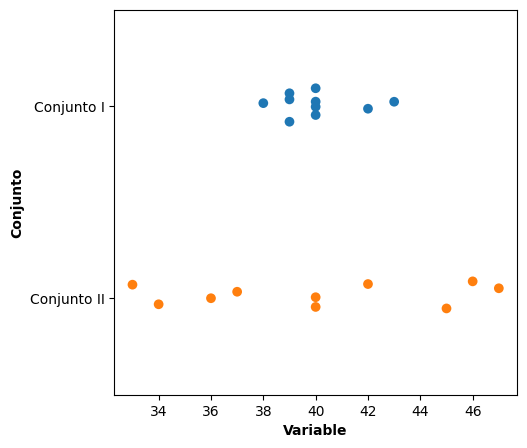

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (5.2,5))

sns.stripplot(x = 'valor', y = 'grupo', hue = 'grupo', size = 7, data = df)
plt.xlabel('Variable', fontweight='bold')
plt.ylabel('Conjunto', fontweight='bold')

plt.show()

Aunque ambos conjuntos comparten la misma media, mediana y moda, el gráfico revela una diferencia sustancial en su distribución. En el Conjunto I, los valores se concentran alrededor de 40 y muestran poca variabilidad. En cambio, en el Conjunto II, las observaciones se encuentran más alejadas del centro y cubren un rango más amplio.

Decimos entonces que el Conjunto II presenta mayor dispersión.

Esta diferencia visual pone de manifiesto que conocer únicamente el centro de los datos no es suficiente. Necesitamos incorporar medidas que cuantifiquen cuánto se apartan las observaciones respecto de ese centro. Estas medidas reciben el nombre de medidas de dispersión y serán desarrolladas a continuación.

Para ilustrar cada medida, utilizaremos la variable ingreso total mensual del hogar (`bhih01`), de la ENFR.

### Rango

El rango es la diferencia entre el mayor y el menor valor observado de la variable:

$$R = X_{max} - X_{min}$$

En Pandas, puede calcularse como:

In [11]:
rango = data.bhih01.max() - data.bhih01.min()

print(rango)

420000


A continuación, una forma de interpretar el valor obtenido en el contexto de los datos de la encuesta:

> ***Los ingresos totales mensuales en los hogares encuestados se encuentran en un rango de \$420000.*** 

```{admonition} **Importante**
:class: important

Si el valor obtenido es elevado en el contexto de los datos con los que estamos trabajando, esto sugiere la presencia de una gran heterogeneidad entre las observaciones. No obstante, es preciso tener presente que **el rango depende exclusivamente de los valores extremos**, por lo que puede verse fuertemente afectado por la existencia de observaciones atípicas.
```

### Varianza y desvío estándar

La varianza mide cuánto se desvían, en promedio, las observaciones respecto de la media aritmética. Se define como:

$$S^2=\frac{1}{n-1}\sum_{i=1}^{n}{(X_i - \bar{X})^2}$$

Cuanto mayor es la variabilidad de los datos, mayor será la varianza.

Por su parte, el desvío estándar es la raíz cuadrada positiva de la varianza:

$$S^2=\sqrt{\frac{1}{n-1}\sum_{i=1}^{n}{(X_i - \bar{X})^2}}$$

En Pandas:

In [12]:
varianza = data.bhih01.var()
desv_est = data.bhih01.std()

print(f"Varianza: {varianza}")
print(f"Desvío estándar: {desv_est}")

Varianza: 390322722.1796636
Desvío estándar: 19756.586804902905


A diferencia de la varianza, el desvío estándar está expresado en las mismas unidades que la variable, lo que facilita su interpretación.

> ***En promedio, los ingresos totales mensuales de los hogares encuestados se desvían aproximadamente \$19756.58 con respecto a la media de \$22446.65.***

### Coeficiente de Variación (CV)

El coeficiente de variación (CV) se define como el cociente entre el desvío estándar y el valor absoluto de la media:

$$CV = \frac{S}{\bar{|X|}}$$

Es una medida adimensional, lo que permite comparar la variabilidad relativa entre variables con distintas unidades o escalas.

En Python:

In [13]:
cv = data.bhih01.std() / data.bhih01.mean()

print(cv)

0.8801573250209908


> ***El desvío estándar del ingreso total mensual de los hogares encuestados representa un 88 % del valor promedio correspondiente.***

Retomando su característica de medida adimensional, supongamos que queremos comparar la dispersión del ingreso mensual de los hogares encuestados en Argentina con la de un estudio análogo realizado en Uruguay.

Más allá de la realidad económica de cada país, dado que los niveles de ingreso están medidos en escalas diferentes por tratarse de monedas distintas, no tendría sentido comparar directamente los desvíos estándar expresados en sus monedas originales. Un mayor desvío estándar en Argentina podría deberse simplemente a que los ingresos están expresados en una escala monetaria numéricamente más alta, y no necesariamente a una mayor variabilidad relativa.

En este sentido, el coeficiente de variación, al ser una medida adimensional, permite comparar la dispersión relativa de los ingresos entre ambos países independientemente de la unidad monetaria utilizada.


### Rango intercuartil (RI)

El rango intercuartil se define como la diferencia entre el tercer y el primer cuartil:

$$RI = Q_3 - Q_1$$

Mide la amplitud del 50% central de los datos y, a diferencia del rango, no se ve afectado por valores extremos.

En Pandas:

In [14]:
q1 = data.bhih01.quantile(0.25)
q3 = data.bhih01.quantile(0.75)

ri = q3 - q1

print(ri)

20000.0


> ***El 50% central de los ingresos totales anuales de los hogares encuestados se encuentra en un rango de \$20000.***

El rango intercuartil es una medida robusta de dispersión y resulta especialmente adecuada cuando se utiliza la mediana como medida de tendencia central.

### Desviación mediana absoluta (MAD)

La desviación mediana absoluta (MAD) es una medida robusta de dispersión basada en la mediana. Se define como:

$$MAD = \text{Mediana}(|X_i - Q_2|)$$

Es decir, es la mediana de las diferencias absolutas entre cada observación y la mediana del conjunto.

Supongamos que tenemos el siguiente conjunto de valores observados: 

$$[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]$$ 

Para calcular la MAD seguimos los siguientes pasos:

1. Calcular la mediana:

$$Q_2 = 6$$

2. Calcular la desviación absoluta de cada observación con respecto a la mediana:

$$[5, 4, 3, 2, 1, 0, 1, 2, 3, 4, 5]$$

3. Ordenar la lista de desviaciones absolutas de menor a mayor: 

$$[0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5]$$

4. Calcular la mediana del conjunto del ítem anterior: 

$$MAD = 3$$

En Python, y considerando el ejemplo de la ENFR con el que venimos trabajando:

In [15]:
mediana = data.bhih01.median()
dif_abs = abs(data.bhih01 - mediana)

mad = dif_abs.median()

print(mad)

9000.0


Interpretación:

> ***El 50 % de los ingresos totales mensuales de los hogares encuestados se aleja de la mediana un total de \$9000 o menos, en valor absoluto.***

La MAD representa la desviación típica respecto de la mediana. Al estar basada en una medida robusta de centralidad, no se ve influenciada por valores extremos, por lo que es especialmente útil en distribuciones asimétricas.

## El método **describe()**

Una forma rápida de obtener varias de las métricas vistas es utilizar el método **`describe()`**:

In [16]:
data.bhih01.describe()

count     29224.000000
mean      22446.653846
std       19756.586805
min           0.000000
25%       10000.000000
50%       18000.000000
75%       30000.000000
max      420000.000000
Name: bhih01, dtype: float64

Como se observa, este método permite obtener un panorama general de la distribución de la variable en una sola salida, ya que devuelve:

- cantidad de observaciones,

- media,

- desvío estándar,

- mínimo y máximo,

- cuartiles.

Apliquémoslo ahora sobre una variable cualitativa, como el *tipo de vivienda* de la Encuesta Nacional de Factores de Riesgo (ENFR 2018). Antes de continuar, recordemos que la variable bhcv01 está codificada numéricamente:

1 = Casa

2 = Casilla

3 = Departamento

4 = Pieza de inquilinato

5 = Pieza en hotel o pensión

6 = Local no construido para habitación

7 = Otros

Por lo tanto, aunque conceptualmente es una variable cualitativa, su tipo de dato en el DataFrame no es categórico:

In [17]:
data['bhcv01'].dtype

dtype('int64')

En este punto, pandas la interpreta como una variable numérica (`int64`).

Si ejecutáramos el `describe()`, obtendríamos media, desvío estándar y percentiles. Sin embargo, estos estadísticos no tienen interpretación sustantiva, ya que los valores 1, 2, 3, … no representan cantidades, sino categorías. Por ejemplo, un promedio de 2.8 no corresponde a ningún tipo real de vivienda.

Esto ocurre porque Pandas decide qué resumen mostrar en función del tipo de dato almacenado, no del significado conceptual de la variable.

La solución conceptual correcta (y sencilla) es indicarle explícitamente que se trata de una variable categórica:

In [18]:
data["bhcv01"] = data["bhcv01"].astype("category")
data.bhcv01.describe()

count     29224
unique        7
top           1
freq      24746
Name: bhcv01, dtype: int64

Ahora `describe()` devuelve:

- `count`

- `unique`

- `top`

- `freq`

que sí son estadísticos adecuados para una variable cualitativa.

Queda como ejercicio propuesto interpretar cada uno de los componentes de esta salida.

## Medidas de forma

Además de describir el centro y la dispersión de una variable cuantitativa, en muchos casos resulta relevante analizar **la forma de su distribución**. Dos medidas clásicas que permiten caracterizarla son el **sesgo** (asimetría) y la **curtosis**. En esta sección abordaremos

### Sesgo (asimetría)

El sesgo mide el grado de asimetría de una distribución respecto de su media.

- Si el sesgo es **cercano a 0**, la distribución es **aproximadamente simétrica**. En este caso, la media, la mediana y la moda tienden a coincidir o a ubicarse muy próximas entre sí.

- Si el sesgo es *positivo**, la distribución presenta una **cola más larga hacia la derecha**. Esto suele implicar que existen algunos valores relativamente altos que “estiran” la distribución hacia ese lado. En este caso, típicamente se verifica: moda < mediana < media.

- Si el sesgo es *negativo**, **la cola se extiende hacia la izquierda**. En este caso, suele observarse: media < mediana < moda.

En términos intuitivos, el sesgo indica hacia qué lado se concentran los valores extremos.

En Python, el coeficiente de asimetría puede calcularse directamente utilizando el método **`skew()`**. 

La siguiente figura ilustra gráficamente los tres casos posibles:

```{figure} imagenes/skewness.png
---
width: 100%
align: center
---
Histogramas que muestran ejemplos de distribuciones simétrica, asimétrica a la derecha (sesgo positivo, *right-skewed*) y asimétrica a la izquierda (sesgo negativo, *left-skewed*). Se indica la posición relativa de la media, la mediana y la moda en cada caso.
```

### Curtosis

La curtosis es una medida de forma que describe el grado en que una distribución se aleja de la **distribución normal** en términos de su apuntamiento (concentración central) y del peso de sus colas.

```{dropdown} Sobre la distribución normal
:class: seealso

La distribución normal (o gaussiana) es una de las distribuciones de probabilidad más importantes en estadística. Tiene forma de campana, es simétrica respecto de su media y queda completamente determinada por dos parámetros:

- la esperanza ($\mu$), que determina el centro,

- la desviación estándar ($\sigma$), que determina la dispersión.

Algunas propiedades relevantes:

- Es simétrica: la esperanza, la mediana y la moda coinciden.

- La mayor parte de los valores se concentra alrededor del centro.

- La probabilidad de observar valores muy alejados de la media decrece rápidamente a medida que nos movemos hacia las colas.

- Aproximadamente:

    - el 68% de los valores cae dentro de $\pm1\sigma$,

    - el 95% dentro de $\pm2\sigma$,

    - el 99.7% dentro de $\pm3\sigma$.

En el estudio de la curtosis, la distribución normal cumple un rol especial: se utiliza como punto de referencia. Cuando hablamos de **exceso de curtosis** (*ver más adelante en el texto principal*), estamos midiendo cuánto se aparta una distribución del nivel de curtosis de la normal.
```

En la distribución normal, el coeficiente de curtosis es igual a 3. Cuando una distribución presenta aproximadamente ese mismo valor, se dice que es **mesocúrtica**.

Si la curtosis es:

- **Mayor que 3**, la distribución se denomina **leptocúrtica**. En este caso, los datos se encuentran más concentrados alrededor de la media que en la distribución normal, lo que produce una forma más "puntiaguda" en el centro. Además, aunque inicialmente la curva decae con mayor rapidez, en los extremos resulta relativamente más alta que la normal. Esto implica una mayor probabilidad de observar valores extremos.

- **Menor que 3**, la distribución se denomina **platicúrtica**. Presenta una menor concentración central y una forma más achatada, con colas relativamente más livianas.

Es importante destacar que la curtosis no mide únicamente la “altura del pico” de la distribución. En realidad, refleja una combinación entre concentración central y comportamiento en las colas. Tampoco debe confundirse con la variabilidad: una distribución leptocúrtica no necesariamente tiene menor varianza por ser más apuntada, ni una platicúrtica mayor varianza por ser más achatada.

En Python, la curtosis puede calcularse mediante el método **`kurt()`**. Es importante señalar que Pandas reporta el **exceso de curtosis**, es decir, la curtosis menos 3. Bajo esta convención, un valor cercano a 0 indica una distribución mesocúrtica (similar a la normal), valores positivos indican leptocurtosis y valores negativos indican platicurtosis.

Al igual que el sesgo, la curtosis es sensible a la presencia de valores extremos, por lo que su interpretación debe realizarse junto con el análisis gráfico de la distribución.

Vamos a analizar tres ejemplos con datos "de juguete":

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Simulamos tres conjuntos de datos con distinta curtosis
np.random.seed(123)

n = 10000

## Set 1) Curtosis ≈ 0 → Normal
normal_data = pd.Series(np.random.normal(loc=0, scale=1, size=n))

## Set 2) Curtosis < 0 (colas más livianas)
### Parámetros: izquierda=-3, moda=0, derecha=3
triangular_data = pd.Series(np.random.triangular(left=-3, mode=0, right=3, size=n))

## Set 3) Curtosis > 0 (colas más pesadas)
laplace_data = pd.Series(np.random.laplace(loc=0, scale=1, size=n))

# Mostramos el exceso de curtosis
print("Exceso de curtosis:")
print("Normal     :", round(normal_data.kurt(), 3))
print("Triangular :", round(triangular_data.kurt(), 3))
print("Laplace    :", round(laplace_data.kurt(), 3))

Exceso de curtosis:
Normal     : -0.03
Triangular : -0.599
Laplace    : 2.786


Observemos los tres conjuntos anteriores representados gráficamente a través de histogramas de frecuencias:

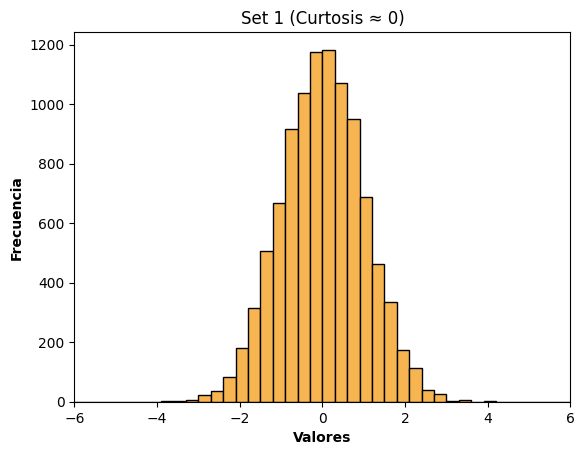

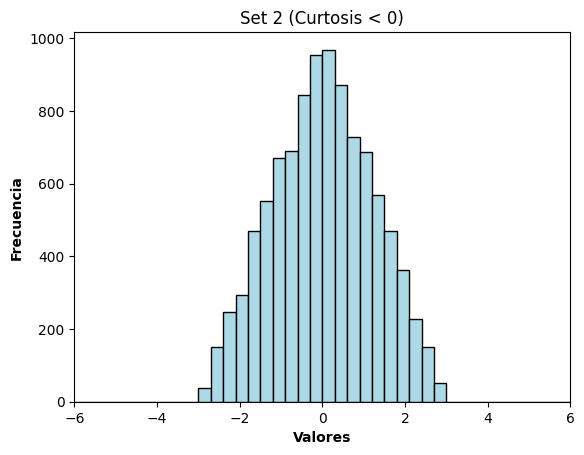

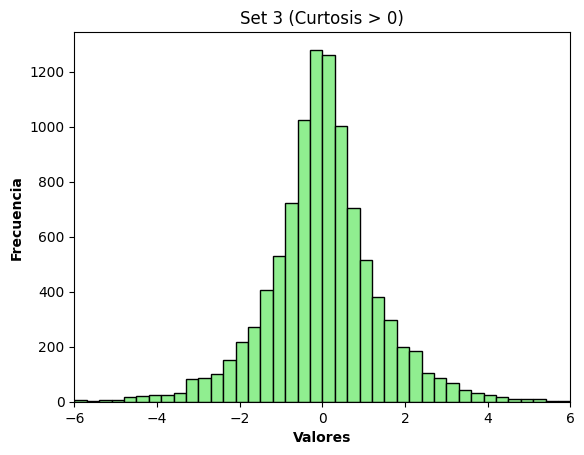

In [20]:
xmin, xmax = -6, 6

# --- Set 1 ---
plt.figure()
plt.hist(normal_data, bins = 40, range = (xmin, xmax), color = '#f7b552', edgecolor = 'black')
plt.title("Set 1 (Curtosis ≈ 0)")
plt.xlabel("Valores", fontweight = 'bold')
plt.ylabel("Frecuencia", fontweight = 'bold')
plt.xlim(xmin, xmax)
plt.show()

# --- Set 2 ---
plt.figure()
plt.hist(triangular_data, bins = 40, range = (xmin, xmax), color = 'lightblue', edgecolor = 'black')
plt.title("Set 2 (Curtosis < 0)")
plt.xlabel("Valores", fontweight = 'bold')
plt.ylabel("Frecuencia", fontweight = 'bold')
plt.xlim(xmin, xmax)
plt.show()

# --- Set 3 ---
plt.figure()
plt.hist(laplace_data, bins = 40, range = (xmin, xmax), color = 'lightgreen', edgecolor = 'black')
plt.title("Set 3 (Curtosis > 0)")
plt.xlabel("Valores", fontweight = 'bold')
plt.ylabel("Frecuencia", fontweight = 'bold')
plt.xlim(xmin, xmax)
plt.show()

## Diagrama de caja y bigotes (boxplot)

Los cuartilos, junto con los valores mínimo y máximo, conforman un conjunto de cinco números que resume de manera muy compacta la información esencial de una variable cuantitativa: dónde se ubican los datos, qué tan concentrados están en torno al centro y cuál es el rango de variación.

A partir de estos cinco valores podemos construir un gráfico llamado **boxplot** (o diagrama de caja y bigotes). El boxplot traduce ese resumen numérico en una representación visual sencilla pero muy potente.

En este gráfico, la parte central está formada por una “caja” que se extiende desde el primer cuartil ($Q_1$) hasta el tercer cuartil ($Q_3$). Esa caja contiene el 50 % central de las observaciones. En su interior se dibuja una línea que marca la mediana, es decir, el valor que divide al conjunto de datos ordenados en dos subconjuntos con aproximadamente el mismo número de observaciones. Desde la caja se proyectan hacia ambos lados los llamados *whiskers* (bigotes), que en la versión clásica llegan hasta el mínimo y el máximo observados.

De este modo, el boxplot permite visualizar de un vistazo la posición central, la dispersión y las características de simetría de la distribución. Sin necesidad de ver todos los datos individuales, obtenemos una síntesis clara de su comportamiento.

```{figure} imagenes/boxplot.png
---
width: 70%
align: center
---
Esquema representativo de un diagrama de caja y bigotes (boxplot) clásico.
```

### El boxplot modificado

Existe una versión modificada del boxplot que permite detectar potenciales *outliers*, es decir, observaciones que no son típicas del conjunto. El criterio comúnmente aceptado considera como potenciales outliers aquellas observaciones que se encuentren por fuera del intervalo:

$$(Q_1 - 1.5 RI)\qquad\qquad\text{y}\qquad\qquad(Q_3 + 1.5 RI)$$

donde $RI = Q_3 - Q_1$ es el rango intercuartílico.

En el boxplot modificado:

- Los *whiskers* ya no llegan necesariamente al mínimo y máximo absolutos, sino que se extienden hasta el valor mínimo y máximo que no sea considerado atípico según el criterio anterior.

- Las observaciones que quedan fuera de esos límites se representan como puntos individuales.

Este formato es el que utilizan la mayoría de los softwares estadísticos por defecto.

Para ilustrar el boxplot modificado, trabajaremos con la variable *minutos semanales de actividad física intensa* (según el diccionario de registros de la ENFR 2018, se trata de actividades que hacen respirar mucho más rápido, exigen mayor esfuerzo físico y aceleran el ritmo cardíaco).

Para el ejemplo, filtraremos únicamente las observaciones correspondientes a la provincia de Santa Fe.

In [21]:
data_stafe = data[data['cod_provincia'] == 82]

Construimos el boxplot utilizando funciones de las librerías `matplotlib` y `seaborn`, que veremos con más detalle en la próxima unidad:

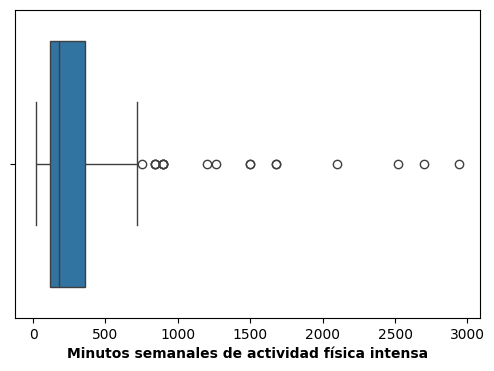

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (6,4))

sns.boxplot(x = 'biaf02_m', data = data_stafe)
plt.xlabel('Minutos semanales de actividad física intensa', fontweight = 'bold')
plt.show()

El gráfico muestra claramente que la distribución de estos datos es asimétrica hacia la derecha, y que hay algunas observaciones que, a la luz del criterio definido anteriormente, son potencialmente atípicas para este conjunto. Notar que el bigote inferior es coincidente con el valor mínimo, mientras que el superior se extiende hasta el máximo valor que se encuentra por debajo de $Q_3 + 1.5 RI$.

Queda como ejercicio propuesto pensar qué medidas de posición y dispersión resultan más representativas para describir a un dataset con estas características.

#### Sobre la interpretación de los *outliers*

Como mencionamos anteriormente, en el contexto del boxplot modificado, un *outlier* es una observación que cae fuera del intervalo definido por

$$(Q_1 - 1.5 RI)\qquad\qquad\text{y}\qquad\qquad(Q_3 + 1.5 RI)$$

Es importante destacar que este criterio es convencional. Fue popularizado por John Tukey en el marco del análisis exploratorio de datos, y su propósito es identificar observaciones inusuales respecto del patrón central de la distribución. **Sin embargo, no constituye una regla que determine automáticamente que un dato sea incorrecto.**

Un *outlier* es, estrictamente, una observación atípica según un criterio estadístico. Eso no implica que sea, necesariamente un error de carga, un valor imposible ni un dato que deba eliminarse.

En muchos contextos, los valores extremos son completamente válidos y forman parte del fenómeno bajo estudio. Por ejemplo:

- En ingresos económicos, es esperable que existan valores muy altos respecto de la mayoría.

- En actividad física semanal, algunas personas pueden reportar minutos de actividad considerablemente superiores al promedio.

- En variables biomédicas, ciertos individuos pueden presentar valores extremos sin que ello implique un error de medición.

**Eliminar observaciones únicamente por el hecho de ser *outliers* puede alterar la distribución original de los datos y sesgar los resultados del análisis.** Por esta razón, ante la detección de valores atípicos, lo adecuado no es eliminarlos automáticamente, sino preguntarse:

- ¿Es un error de medición o de carga?

- ¿Es un valor posible dentro del fenómeno estudiado?

- ¿El objetivo del análisis justifica conservarlo o tratarlo de manera especial?

**¿Cuándo puede justificarse excluir un outlier?**

Si bien los valores atípicos no deben eliminarse automáticamente, existen situaciones en las que su exclusión puede estar justificada. En particular, cuando hay evidencia de que el valor:

- corresponde a un error de carga o digitación (por ejemplo, un cero de más en un ingreso),

- es físicamente imposible (edad negativa, 500 horas de actividad física en una semana, etc.),

- proviene de una falla de medición documentada,

- o no pertenece realmente a la población objetivo del estudio (error de clasificación).

**En estos casos, la exclusión no se basa en que el valor sea “extremo”, sino en que existe una razón sustantiva o técnica para considerarlo inválido.**

También puede ocurrir que, aun siendo correcto, un valor extremo tenga una influencia desproporcionada sobre los valores de ciertas estadísticas, como la media aritmética o las estimaciones de los coeficientes de un modelo estadístico (Unidad 6). En esos casos, en lugar de eliminarlo sin más, es recomendable: analizar el resultado con y sin esa observación, utilizar medidas más robustas (como la mediana) o aplicar métodos estadísticos diseñados para reducir la influencia de valores extremos.

En cualquier caso, una buena práctica es documentar explícitamente cualquier criterio de exclusión aplicado. La transparencia metodológica es parte central del análisis de datos.

#### Consideraciones importantes sobre el ploteo de los *outliers*

En algunas situaciones puede resultar de interés construir la versión clásica del boxplot, es decir, aquella en la que los *whiskers* se extienden hasta el valor mínimo y máximo observados, sin identificar ni marcar potenciales valores atípicos.

Esto puede ser útil cuando el tamaño del dataset es muy grande. En esos casos, el boxplot modificado puede volverse difícil de leer: una proporción considerable de observaciones puede quedar fuera del criterio $1.5 RI$, generando una gran cantidad de puntos individuales que incluso pueden ocultar la caja.

En **`sns.boxplot()`**, existe el parámetro `showfliers = False`, que evita que se dibujen los potenciales *outliers*. Sin embargo, es importante notar que esta opción no construye el boxplot clásico. El criterio del boxplot modificado se mantiene: los *whiskers* se extienden hasta el valor mínimo y máximo observados que se encuentren dentro del intervalo definido por $Q_1 - 1.5 RI$ y $Q_3 + 1.5 RI$. Lo único que cambia es que las observaciones que quedan fuera de esos límites no se muestran en el gráfico.

En términos gráficos, esto equivale a “recortar” el boxplot y ocultar observaciones que efectivamente existen. Si el objetivo es analizar la distribución completa, esta no es una buena elección.

Una forma más apropiada de construir el boxplot clásico sin eliminar ni ocultar datos es modificar el parámetro **`whis`**, extendiendo los *whiskers* hasta el menor y mayor valor observado:

```python
whis = [0, 100]
```

De esta manera, el gráfico respeta la totalidad de los datos y reproduce el esquema original basado en el resumen de cinco números.

**Ejemplo comparativo**

Trabajemos nuevamente con la variable de minutos semanales de actividad física intensa en Santa Fe.

**1. Boxplot modificado (por defecto)**

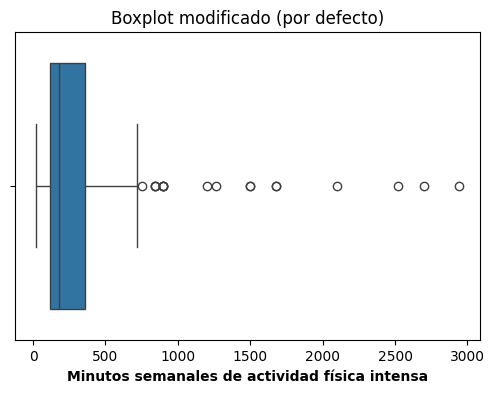

In [23]:
plt.figure(figsize = (6,4))

sns.boxplot(x = 'biaf02_m', data = data_stafe)
plt.title("Boxplot modificado (por defecto)")
plt.xlabel("Minutos semanales de actividad física intensa", fontweight = 'bold')
plt.show()

Aquí los *whiskers* se cortan según el criterio mencionado anteriormente y los potenciales *outliers* aparecen como puntos.

**2. Ocultando los outliers (¡PELIGRO!)**

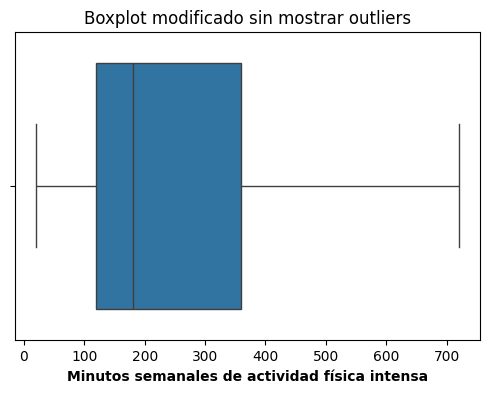

In [24]:
plt.figure(figsize = (6,4))

sns.boxplot(x = 'biaf02_m', data = data_stafe, showfliers = False)
plt.title("Boxplot modificado sin mostrar outliers")
plt.xlabel("Minutos semanales de actividad física intensa", fontweight = 'bold')
plt.show()

En este caso, los valores extremos siguen fuera del rango de los *whiskers*, pero simplemente no se dibujan. La distribución queda parcialmente “recortada”.

**3. Boxplot clásico (*whiskers* hasta mínimo y máximo)**

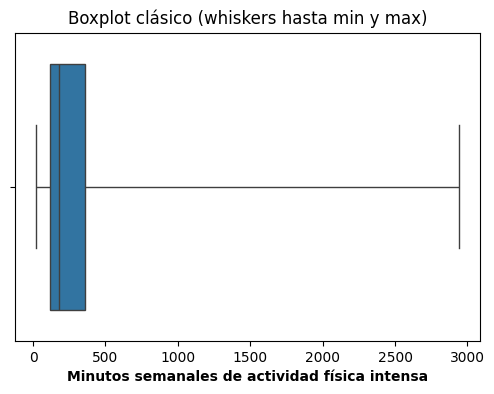

In [25]:
plt.figure(figsize = (6,4))

sns.boxplot(x = 'biaf02_m', data = data_stafe, whis = [0,100])
plt.title("Boxplot clásico (whiskers hasta min y max)")
plt.xlabel("Minutos semanales de actividad física intensa", fontweight = 'bold')
plt.show()

Aquí los *whiskers* se extienden hasta el mínimo y máximo observados. No se eliminan datos ni se altera la representación de la distribución.


## Tabla de frecuencias

Una tabla de frecuencias constituye una forma sencilla y efectiva de resumir la información contenida en las observaciones de una variable.

### Variables cualitativas

Cuando la variable es cualitativa, la tabla presenta las distintas categorías observadas, el número de veces que aparece cada una (frecuencia absoluta), y, si se desea, su frecuencia relativa o porcentaje sobre el total.

Como ejemplo, trabajemos con la variable `bhcv01` (*tipo de vivienda*). Recordemos que la misma se encuentra codificada numéricamente de la siguiente manera:

1 = Casa

2 = Casilla

3 = Departamento

4 = Pieza de inquilinato

5 = Pieza en hotel o pensión

6 = Local no construido para habitación

7 = Otros

Para que la tabla resulte interpretable, primero conviene recodificar los valores. De esta manera, trabajaremos con etiquetas en lugar de códigos numéricos.

In [26]:
# Creamos un diccionario de etiquetas
map_vivienda = {
    1: "Casa",
    2: "Casilla",
    3: "Departamento",
    4: "Pieza de inquilinato",
    5: "Pieza en hotel o pensión",
    6: "Local no construido para habitación",
    7: "Otros"
}

# Creamos una nueva variable que contenga las categorías correspondientes
data["tipo_vivienda"] = data["bhcv01"].map(map_vivienda)

/tmp/ipykernel_2789/1126856518.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["tipo_vivienda"] = data["bhcv01"].map(map_vivienda)


Una forma simple de construir la tabla es utilizar `value_counts()`:

In [27]:
data["tipo_vivienda"].value_counts()

tipo_vivienda
Casa                                   24746
Departamento                            3992
Casilla                                  312
Pieza de inquilinato                      79
Pieza en hotel o pensión                  49
Otros                                     33
Local no construido para habitación       13
Name: count, dtype: int64

Pero podemos organizarla mejor:

In [28]:
tabla_vivienda = (data["tipo_vivienda"].value_counts().reset_index())

tabla_vivienda.columns = ["Tipo de vivienda", "Frec_absoluta"]
tabla_vivienda = tabla_vivienda.set_index("Tipo de vivienda")

tabla_vivienda

,Frec_absoluta
Tipo de vivienda,
Casa,24746
Departamento,3992
Casilla,312
Pieza de inquilinato,79
Pieza en hotel o pensión,49
Otros,33
Local no construido para habitación,13


La columna `Frec_absoluta` indica la cantidad de veces que aparece cada categoría en el dataset. Sin embargo, en muchos contextos resulta más informativo expresar estas cantidades en términos relativos, es decir, como proporción o porcentaje sobre el total de observaciones.

Podemos agregar ambas medidas directamente a la misma tabla:

In [29]:
tabla_vivienda["Frec_relativa"] = (
    tabla_vivienda["Frec_absoluta"] /
    tabla_vivienda["Frec_absoluta"].sum()
)

tabla_vivienda["Porcentaje"] = (tabla_vivienda["Frec_relativa"] * 100).round(1)

tabla_vivienda

,Frec_absoluta,Frec_relativa,Porcentaje
Tipo de vivienda,,,
Casa,24746,0.846770,84.7
Departamento,3992,0.136600,13.7
Casilla,312,0.010676,1.1
Pieza de inquilinato,79,0.002703,0.3
Pieza en hotel o pensión,49,0.001677,0.2
Otros,33,0.001129,0.1
Local no construido para habitación,13,0.000445,0.0


La frecuencia relativa toma valores entre 0 y 1 y representa la proporción de cada categoría respecto del total. El porcentaje no es más que esa misma proporción multiplicada por 100, lo que facilita su interpretación en términos más habituales.

De esta manera, la tabla reúne en un único objeto la información esencial para describir la variable: cuántas veces aparece cada tipo de vivienda y qué peso relativo tiene dentro del conjunto de datos.

A partir de esta tabla podemos construir un **gráfico de barras**, que es la representación gráfica natural de una variable cualitativa:

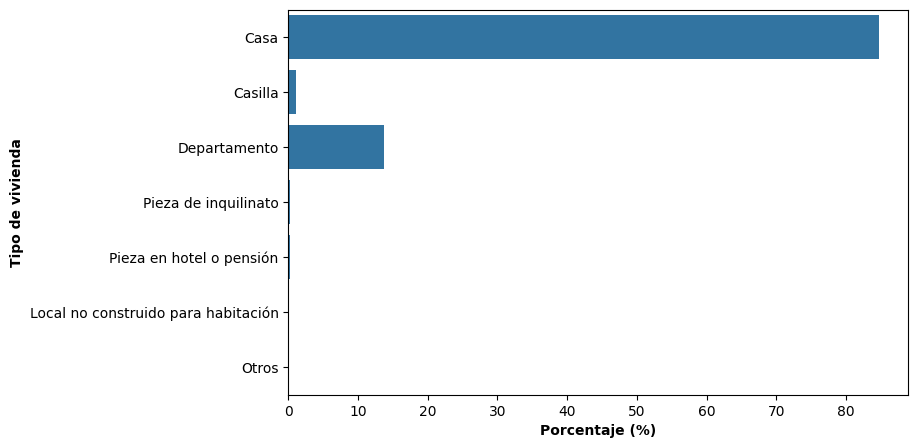

In [30]:
plt.figure(figsize = (8,5))

sns.barplot(x = 'Porcentaje', y = tabla_vivienda.index, data = tabla_vivienda)

plt.xlabel("Porcentaje (%)", fontweight="bold")
plt.ylabel("Tipo de vivienda", fontweight="bold")
plt.show()

El gráfico permite visualizar rápidamente cuál es la categoría más frecuente y cómo se distribuyen las demás, complementando la información numérica de la tabla.

En algunos casos, como en el ejemplo, la distribución puede estar fuertemente concentrada en pocas categorías, mientras que otras presentan frecuencias muy bajas. Esto puede generar gráficos en los que algunas barras resultan prácticamente imperceptibles. 

Frente a esta situación, una estrategia posible consiste en agrupar las categorías menos frecuentes en una nueva categoría, por ejemplo “Otros tipos”, con el objetivo de facilitar la visualización. Sin embargo, esta decisión no es neutra: implica modificar la estructura original de la variable. Por lo tanto, su utilización debe estar justificada por el objetivo del análisis.

Si el propósito es describir con precisión la distribución original, conviene conservar todas las categorías. Si el objetivo es comunicar tendencias generales o simplificar la presentación, puede ser razonable agrupar aquellas con muy baja frecuencia.

En cualquier caso, la recodificación debe explicitarse y documentarse, como se muestra a continuación:

In [31]:
# Identificamos categorías con menos del 3% de frecuencia en la tabla original
categorias_principales = tabla_vivienda[
    tabla_vivienda["Porcentaje"] >= 3
].index

# Unificamos las categorías menos frecuentes en "Otros tipos"
data["tipo_vivienda_agrupada"] = data["tipo_vivienda"].apply(
    lambda x: x if x in categorias_principales else "Otros tipos"
)

/tmp/ipykernel_2789/1773924840.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["tipo_vivienda_agrupada"] = data["tipo_vivienda"].apply(


La tabla resultante se vería así:

In [32]:
tabla_vivienda_resumida = (data["tipo_vivienda_agrupada"].value_counts().reset_index())

tabla_vivienda_resumida.columns = ["Tipo de vivienda", "Frec_absoluta"]
tabla_vivienda_resumida = tabla_vivienda_resumida.set_index("Tipo de vivienda")

# Agregamos columna con Porcentajes
tabla_vivienda_resumida["Porcentaje"] = (
    tabla_vivienda_resumida["Frec_absoluta"]*100/
    tabla_vivienda["Frec_absoluta"].sum()
).round(1)

tabla_vivienda_resumida

,Frec_absoluta,Porcentaje
Tipo de vivienda,,
Casa,24746,84.7
Departamento,3992,13.7
Otros tipos,486,1.7


El gráfico de barras ahora luciría así:

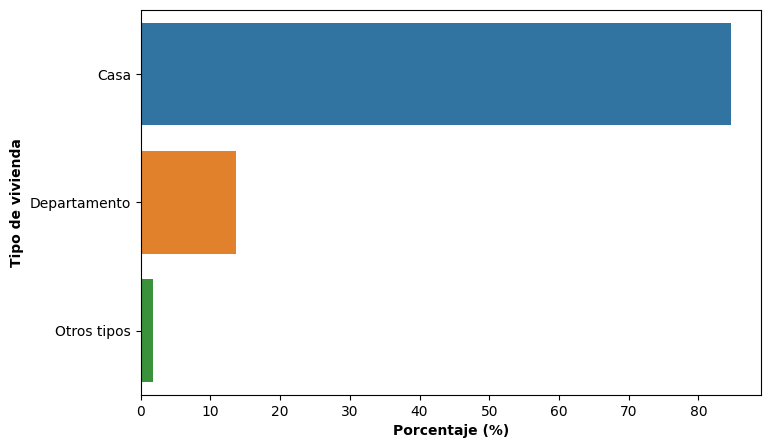

In [33]:
plt.figure(figsize = (8,5))

sns.barplot(x = 'Porcentaje', y = tabla_vivienda_resumida.index, hue = tabla_vivienda_resumida.index, data = tabla_vivienda_resumida)

plt.xlabel("Porcentaje (%)", fontweight="bold")
plt.ylabel("Tipo de vivienda", fontweight="bold")
plt.show()

Es importante señalar que dentro de la categoría *Otros tipos* se agrupan diversas modalidades de vivienda originalmente diferenciadas (pieza de inquilinato, pieza en hotel o pensión, local no construido para habitación, entre otras). Esta decisión mejora la legibilidad del gráfico, pero reduce el nivel de detalle disponible en la descripción de la variable.

### Variables cuantitativas discretas

Cuando trabajamos con variables cuantitativas discretas, los valores que puede tomar la variable son numéricos y separados entre sí. En muchos casos —como ocurre con la edad medida en años cumplidos, el número de ambientes o de miembros de un hogar o el número de días por semana que una persona realiza actividad física— la variable puede asumir varios valores posibles, pero estos tienen la característica de ser numerables.

Si el número de observaciones es grande, pero la variable presenta un conjunto acotado de valores distintos (como muchas veces ocurre cuando trabajamos con datos de variables cuantitativas discretas), es posible construir una tabla de frecuencias similar a la utilizada para variables cualitativas. En este caso, cada fila de la tabla representa un valor numérico posible y la frecuencia absoluta indica cuántas viviendas presentan ese número de miembros.

En nuestro conjunto de datos contamos con la variable `cant_componentes`, que registra la cantidad de miembros del hogar encuestado. Podemos resumir su distribución mediante una tabla de frecuencias de la siguiente manera:

In [34]:
# Tabla de frecuencias para la cantidad de miembros del hogar
tabla_miembros = (data['cant_componentes'].value_counts().sort_index().reset_index())

tabla_miembros.columns = ["Num_miembros", "Frec_absoluta"]

tabla_miembros

,Num_miembros,Frec_absoluta
0,1,6630
1,2,7760
2,3,5664
3,4,4786
4,5,2458
5,6,1102
6,7,459
7,8,205
8,9,77
9,10,47


En este caso, cada fila corresponde a un número específico de miembros del hogar y la columna `Frec_absoluta` indica cuántas viviendas encuestadas tienen ese número de miembros dentro del conjunto de datos. 

Dado que se trata de una variable cuantitativa discreta, la representación gráfica adecuada es un **gráfico de bastones**. 

Podemos construirlo utilizando el DataFrame anterior y la función `plt.bar()`. Si fijamos un ancho suficientemente pequeño (por ejemplo, `width = 0.25`), las barras adquieren la forma visual de bastones:

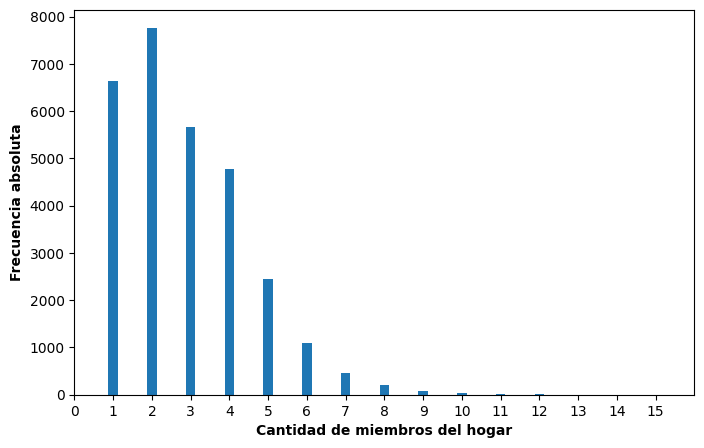

In [35]:
plt.figure(figsize=(8,5))

plt.bar(tabla_miembros['Num_miembros'], tabla_miembros['Frec_absoluta'], width = 0.25)

plt.xlabel("Cantidad de miembros del hogar", fontweight = "bold")
plt.ylabel("Frecuencia absoluta", fontweight = "bold")

plt.xlim((0,16))
plt.xticks(np.arange(0,16,1))

plt.show()

El gráfico permite visualizar que la distribución de cantidad de miembros de las viviendas encuestadas es asimétrica hacia la derecha. Se observa que la mayor parte de los hogares tiene pocos miembros, mientras que los hogares con muchos integrantes son relativamente menos frecuentes.

### Variables cuantitativas continuas

Cuando trabajamos con variables cuantitativas continuas, la situación es diferente a la de las variables discretas. Estas variables pueden tomar, al menos en teoría, infinitos valores dentro de un intervalo.

Un ejemplo típico es el ingreso mensual del hogar. Desde el punto de vista conceptual, el ingreso es una magnitud continua: podría medirse con el nivel de precisión que quisiéramos (pesos, centavos, fracciones de centavo, etc.). Sin embargo, en los datos suele registrarse en unidades enteras (por ejemplo, en pesos, como ocurre en la ENFR), lo que hace que los valores observados aparezcan discretizados.

Es importante distinguir entonces entre:

- la naturaleza teórica de la variable (continua) 

- y la forma en que fue medida o registrada en el dataset.

Aunque en nuestra base de datos el ingreso figure sin decimales, **puede asumir un gran número de valores diferentes**. Si intentáramos construir una tabla de frecuencias considerando cada valor individual observado, obtendríamos una tabla muy extensa y poco informativa.

Por ello, en lugar de trabajar con valores puntuales, **realizamos un agrupamiento en subintervalos (segmentación)**. 

Lo primero es obtener un resumen descriptivo:

In [36]:
data['bhih01'].describe()

count     29224.000000
mean      22446.653846
std       19756.586805
min           0.000000
25%       10000.000000
50%       18000.000000
75%       30000.000000
max      420000.000000
Name: bhih01, dtype: float64

Este resumen nos permite conocer el rango en el que se encuentran las observaciones de la variable, su dispersión en términos de la desviación estándar y algunos percentiles relevantes. A partir de esta información podemos decidir cómo construir los intervalos.

Dado que los ingresos totales mensuales por hogar se encuentran en el rango de 0 a 420000 pesos, podríamos agruparlos en intervalos de igual amplitud, por ejemplo de 40000 pesos:

- [0, 40000)

- [40000, 80000)

- [80000, 120000)

- [120000, 160000)

- [160000, 200000)

- [200000, 240000)

- [240000, 280000)

- [280000, 320000)

- [320000, 360000)

- [360000, 400000)

- [400000, 440000)

Estos intervalos son contiguos y no se superponen. La notación [a, b) indica que el intervalo incluye el límite inferior pero excluye el superior.

Para generarlos utilizamos **`pd.cut()`**:

In [37]:
# Generamos los subintervalos

bins_ingresos = np.arange(0, 450000, 40000)

data['ingreso_seg'] = pd.cut(data['bhih01'], bins = bins_ingresos, right = False)

data['ingreso_seg'].head()

/tmp/ipykernel_2789/719967430.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['ingreso_seg'] = pd.cut(data['bhih01'], bins = bins_ingresos, right = False)


0     [40000, 80000)
1     [40000, 80000)
2     [40000, 80000)
3    [80000, 120000)
4         [0, 40000)
Name: ingreso_seg, dtype: category
Categories (11, interval[int64, left]): [[0, 40000) < [40000, 80000) < [80000, 120000) < [120000, 160000) ... [280000, 320000) < [320000, 360000) < [360000, 400000) < [400000, 440000)]

A partir de esta segmentación construimos la tabla de frecuencias:

In [38]:
tabla_ingresos = data['ingreso_seg'].value_counts().sort_index()

tabla_ingresos

ingreso_seg
[0, 40000)          25064
[40000, 80000)       3581
[80000, 120000)       456
[120000, 160000)       75
[160000, 200000)       16
[200000, 240000)       11
[240000, 280000)        7
[280000, 320000)        5
[320000, 360000)        7
[360000, 400000)        0
[400000, 440000)        2
Name: count, dtype: int64

Formateamos la tabla:

In [39]:
tabla_ingresos = tabla_ingresos.reset_index()
tabla_ingresos.rename(columns = {'ingreso_seg':'Ingreso', 'count':'Frec_absoluta'}, inplace = True)
tabla_ingresos = tabla_ingresos.set_index('Ingreso')

tabla_ingresos

,Frec_absoluta
Ingreso,
"[0, 40000)",25064
"[40000, 80000)",3581
"[80000, 120000)",456
"[120000, 160000)",75
"[160000, 200000)",16
"[200000, 240000)",11
"[240000, 280000)",7
"[280000, 320000)",5
"[320000, 360000)",7


Agregamos la frecuencia relativa correspondiente a cada subintervalo:

In [40]:
tabla_ingresos['Frec_relativa'] = (
    tabla_ingresos['Frec_absoluta'] /
    tabla_ingresos['Frec_absoluta'].sum()
).round(5)

tabla_ingresos

,Frec_absoluta,Frec_relativa
Ingreso,,
"[0, 40000)",25064,0.85765
"[40000, 80000)",3581,0.12254
"[80000, 120000)",456,0.01560
"[120000, 160000)",75,0.00257
"[160000, 200000)",16,0.00055
"[200000, 240000)",11,0.00038
"[240000, 280000)",7,0.00024
"[280000, 320000)",5,0.00017
"[320000, 360000)",7,0.00024


Y las frecuencias acumuladas:

In [41]:
tabla_ingresos['Frec_absoluta_cum'] = (tabla_ingresos['Frec_absoluta'].cumsum())

tabla_ingresos['Frec_relativa_cum'] = (tabla_ingresos['Frec_relativa'].cumsum())

tabla_ingresos

,Frec_absoluta,Frec_relativa,Frec_absoluta_cum,Frec_relativa_cum
Ingreso,,,,
"[0, 40000)",25064,0.85765,25064,0.85765
"[40000, 80000)",3581,0.12254,28645,0.98019
"[80000, 120000)",456,0.01560,29101,0.99579
"[120000, 160000)",75,0.00257,29176,0.99836
"[160000, 200000)",16,0.00055,29192,0.99891
"[200000, 240000)",11,0.00038,29203,0.99929
"[240000, 280000)",7,0.00024,29210,0.99953
"[280000, 320000)",5,0.00017,29215,0.99970
"[320000, 360000)",7,0.00024,29222,0.99994


Recordemos:

La **frecuencia absoluta acumulada** indica cuántos hogares tienen ingresos menores al límite superior del intervalo correspondiente.

La **frecuencia relativa acumulada** expresa esa misma cantidad en proporción al total de observaciones.

Este tipo de tabla nos permite resumir la distribución sin trabajar con cada valor individual.

**Interpretación de una fila de la tabla**

Interpretemos a continuación cada una de las frecuencias que figuran en la fila de la tabla correspondiente al subintervalo [40000, 80000):

> ***3581 hogares presentan un ingreso total mensual mayor o igual a \$40000 y menor a \$80000, lo que representa el 12 % de las viviendas encuestadas.***

Las frecuencias acumuladas hasta ese intervalo nos permiten observar que:

> ***28645 hogares presentan un ingreso total mensual menor a los \$80000, lo que representa el 98.02 % de las viviendas encuestadas. En consecuencia, sólo el 1.98 % de los hogares relevado tiene ingresos totales mensuales de \$80000 o más.*** 

#### Histograma de frecuencias

La representación gráfica más adecuada para variables cuantitativas continuas es el **histograma**. A diferencia del gráfico de bastones utilizado para variables discretas:

- Aquí se representan rectángulos contiguos, cuya base abarca cada subintervalo.

- El área del rectángulo representa la frecuencia correspondiente a cada subintervalo. Cuando los intervalos tienen igual amplitud (como en este caso), la altura de la barra es directamente proporcional a la frecuencia.

Podemos construirlo directamente a partir de la variable original:

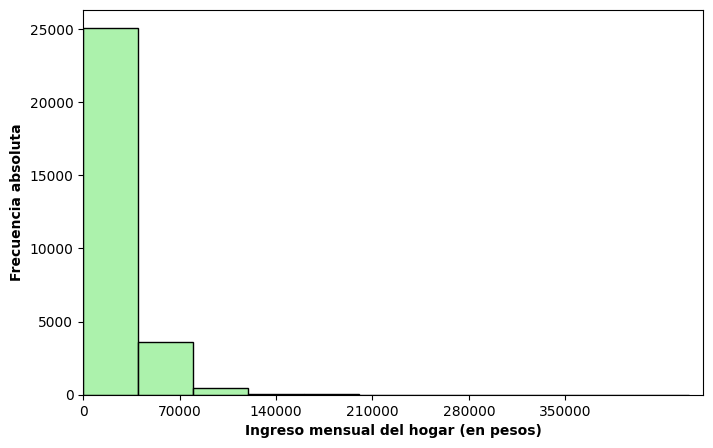

In [42]:
plt.figure(figsize=(8,5))

sns.histplot(x = 'bhih01', bins = bins_ingresos, color = 'lightgreen', edgecolor = 'black', data = data)

plt.xlabel("Ingreso mensual del hogar (en pesos)", fontweight = "bold")
plt.xticks(np.arange(0, 380000, 70000))
plt.ylabel("Frecuencia absoluta", fontweight = "bold")

plt.xlim(0, 450000)

plt.show()

El histograma permite visualizar la forma general de la distribución: concentración de valores, asimetría y comportamiento en las colas.

En este caso, se observa que la distribución es asimétrica hacia la derecha: una gran proporción de hogares se concentra en niveles de ingreso bajos o medios, mientras que un número relativamente pequeño de hogares presenta ingresos elevados.

#### Sobre la elección del número de intervalos

La elección del número de intervalos (bins) no es arbitraria. Si utilizamos muy pocos intervalos, perdemos detalle. Si utilizamos demasiados, el gráfico se vuelve ruidoso y difícil de interpretar.

Cuando el tamaño del dataset es grande, suele ser conveniente aumentar la cantidad de intervalos. Por ejemplo, si utilizamos 50 bins:

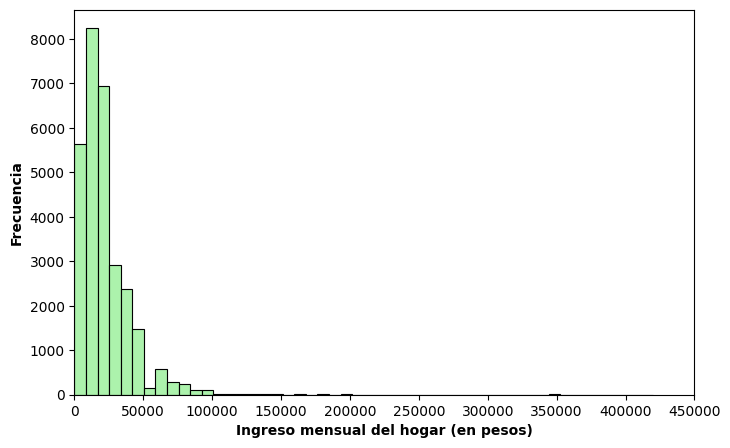

In [43]:
plt.figure(figsize = (8,5))

sns.histplot(x = 'bhih01', bins = 50, color = 'lightgreen', edgecolor = 'black', data = data)

plt.xlabel("Ingreso mensual del hogar (en pesos)", fontweight="bold")
plt.ylabel("Frecuencia", fontweight="bold")

plt.xlim(0, 450000)

plt.show()

En este caso, se aprecia mayor detalle en la estructura de la distribución. Por ejemplo, puede observarse que el intervalo modal no se encuentra exactamente en el tramo inicial y que aparecen máximos locales adicionales en determinados rangos de ingreso.

## Métricas de correlación

### Introducción
En el análisis de datos, muchas veces no alcanza con estudiar variables de manera aislada. En cambio, nos interesa comprender cómo dos variables se comportan conjuntamente.

El **análisis de correlación** tiene como objetivo estudiar el comportamiento conjunto de dos variables aleatorias $X$ e $Y$, es decir, el grado en que ambas varían o cambian juntas.

Antes de cuantificar esta relación con una métrica (como veremos más adelante), es fundamental explorar los datos visualmente.

### Dataset de ejemplo: Penguins

A lo largo de este capítulo utilizaremos el dataset **penguins**, que contiene información sobre 344 pingüinos observados en el Archipiélago Palmer, en la Antártida.

```{figure} imagenes/penguin.png
---
width: 70%
align: center
---
```

Este dataset incluye variables como:

- especie

- isla

- longitud de la aleta (`flipper_length_mm`)

- masa corporal (`body_mass_g`)

entre otras...

Podemos cargarlo fácilmente desde `seaborn`:

In [44]:
import seaborn as sns
df = sns.load_dataset('penguins')

df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


### Análisis univariado

Antes de estudiar la relación entre variables, es importante entender cada una por separado. A continuación, nos enfocaremos particularmente en la longitud de la aleta y la masa corporal del pingüino.

In [45]:
df[['flipper_length_mm', 'body_mass_g']].describe().round(2)

,flipper_length_mm,body_mass_g
count,342.00,342.00
mean,200.92,4201.75
std,14.06,801.95
min,172.00,2700.00
25%,190.00,3550.00
50%,197.00,4050.00
75%,213.00,4750.00
max,231.00,6300.00


A partir del resumen que nos proporciona el método `describe()`, podemos realizar algunas observaciones sobre el conjunto de datos de cada una de estas variables. Así, podemos dar respuesta, por ejemplo, a las siguientes preguntas:

- **¿Cuál es la longitud de aleta promedio de los pingüinos?** La longitud de aleta promedio entre los pingüinos es de 200.92 mm.

- **¿Qué porcentaje de los pingüinos pesa más de 4750 g?** Un 25 % de los pingüinos pesa más de 4750 g, ya que ese valor corresponde al tercer cuartil ($Q_3$): el punto por debajo del cual se concentra el 75 % de las observaciones.

Una forma muy útil de complementar el análisis descriptivo es mediante boxplots:

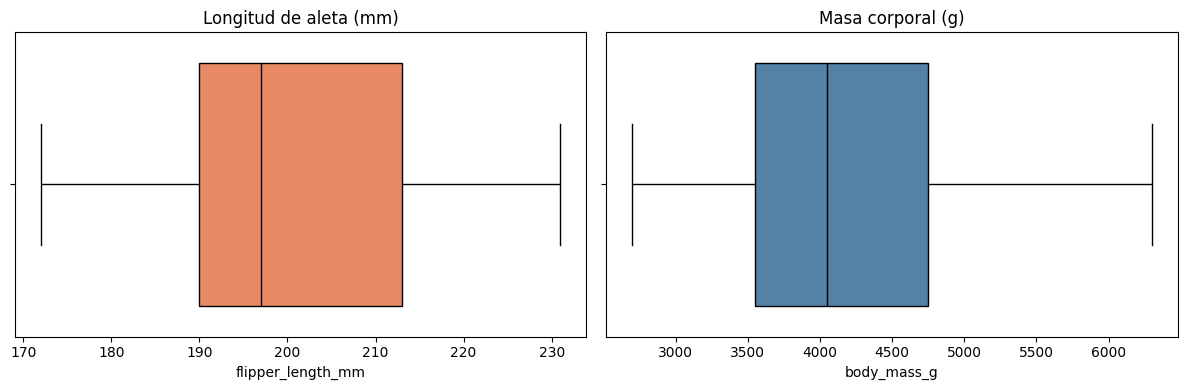

In [46]:
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

sns.boxplot(x = 'flipper_length_mm', color = 'coral', linecolor = 'black', data = df, ax = axes[0])
axes[0].set_title('Longitud de aleta (mm)')

sns.boxplot(x = 'body_mass_g', color = 'steelblue', linecolor = 'black', data = df, ax=axes[1])
axes[1].set_title('Masa corporal (g)')

plt.tight_layout()
plt.show()

### Análisis bivariado

Una vez estudiadas las variables individualmente, podemos preguntarnos: **¿Existe alguna relación entre la longitud de la aleta y el peso de los pingüinos?**.

Un primer acercamiento a una posible respuesta a esta pregunta, consiste en representar gráficamente la información de ambas variables. Un ***scatterplot*** o **gráfico de dispersión** muestra la relación entre dos variables cuantitativas. Los valores de una variable se grafican en el eje de abscisas y los de la otra, en el de las ordenadas. Cada par de observaciones viene representado en el gráfico por un punto.

El gráfico puede revelar la naturaleza de la relación entre las variables, analizando las siguientes características:

- **FORMA:** cuando los puntos del gráfico de dispersión se sitúan aproximadamente a lo largo de una recta se dice que la relación es lineal. Otras formas que pueden presentarse son agrupaciones, relaciones curvilíneas u otras no definidas o claras.

- **DIRECCIÓN:** si la relación entre las dos variables tiene una dirección clara, decimos que existe una asociación positiva cuando a valores mayores de una variable le corresponden en general valores mayores de la otra o negativa en el caso en que a valores menores de una variable le corresponden valores mayores de la otra.

- **INTENSIDAD:** la fuerza de la relación estará dada por la proximidad de los puntos a la función matemática que se supone describe el comportamiento de una variable en función de la otra. En el caso de relaciones lineales, que es el que abordaremos con las métricas de este capítulo, esta referencia es una recta.

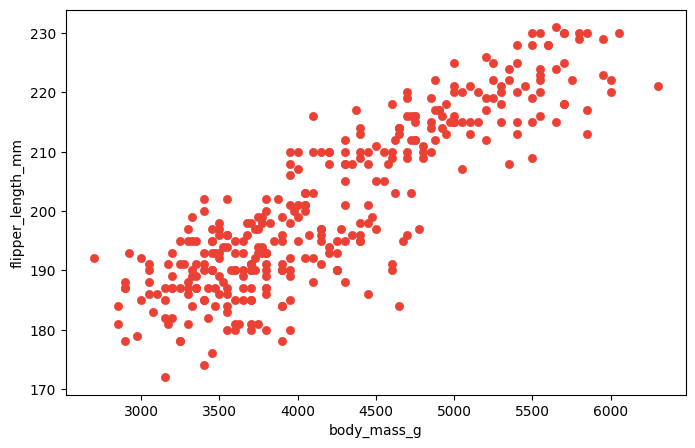

In [47]:
plt.figure(figsize = (8,5))

sns.scatterplot(x = 'body_mass_g', y = 'flipper_length_mm', s = 35, color = '#eb4034', edgecolor = '#eb4034', data = df)
plt.show()

A partir del gráfico anterior se observa que la relación entre la longitud de la aleta y la masa corporal de los pingüinos es lineal, directa y moderada a intensa.

### Covarianza

Para comenzar a cuantificar la relación entre dos variables, volvamos al gráfico de dispersión e incorporemos un elemento clave: las medias de ambas variables ($\bar{x}$ y $\bar{y}$). Del análisis univariado que realizamos en una sección anterior, sabemos que $\bar{x} = 4201.75$ y $\bar{y} = 200.92$.

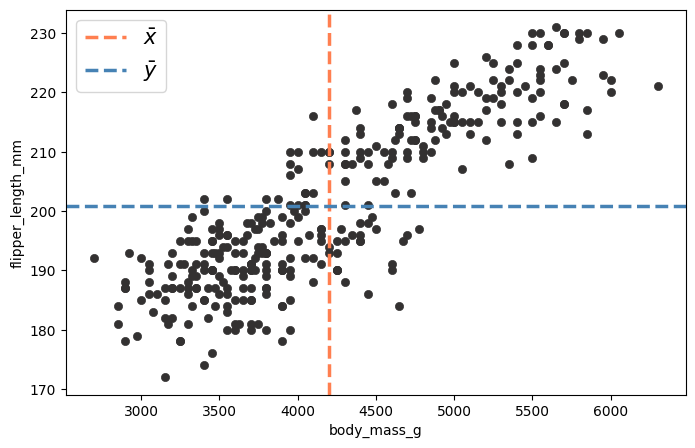

In [48]:
plt.figure(figsize = (8,5))

sns.scatterplot(x = 'body_mass_g', y = 'flipper_length_mm', data = df, s = 35, color = '#333131', edgecolor = '#333131')
plt.axvline(df['body_mass_g'].mean(), color = 'coral', linewidth = 2.5, linestyle = '--', label = r'$\bar{x}$')
plt.axhline(df['flipper_length_mm'].mean(), color = 'steelblue', linewidth = 2.5, linestyle = '--', label = r'$\bar{y}$')
plt.legend(fontsize = 15)
plt.show()

Como se observa, estas dos rectas dividen el plano en **cuatro cuadrantes**, y cada punto del gráfico queda ubicado en uno de ellos según si sus valores están por encima o por debajo de las medias. La pregunta que queremos responder es: **¿cómo construir una métrica que capture si las variables tienden a crecer juntas o a moverse en sentidos opuestos?**

Una forma natural de responderla es analizar, para cada observación ($x_i$, $y_i$), cómo se comportan sus desvíos respecto de las medias. En particular, podemos calcular el producto:

$$(x_i - \bar{x})(y_i - \bar{y})$$

El signo de este producto depende del cuadrante en el que se encuentre cada punto:

- En el **cuadrante superior derecho** (donde $x_i > \bar{x}$ y $y_i > \bar{y}$) y en el **inferior izquierdo** (donde $x_i < \bar{x}$ y $y_i < \bar{y}$), ambos factores tienen el mismo signo, por lo que el producto **es positivo**.

- En el **cuadrante superior izquierdo** (donde $x_i < \bar{x}$ y $y_i > \bar{y}$) y en el **inferior derecho** (donde $x_i > \bar{x}$ y $y_i < \bar{y}$), los factores tienen signos opuestos, por lo que el producto **es negativo**.

Cuando existe una asociación positiva entre las variables —como la que observamos en nuestro gráfico—, la mayoría de los puntos se concentran en los cuadrantes superior derecho e inferior izquierdo, donde el producto es positivo. Si promediamos estos productos sobre todas las observaciones, el resultado será un número positivo. Lo opuesto ocurre cuando la asociación es negativa.

Esta idea se formaliza a través de la **covarianza**:

$$S_{xy} = \frac{1}{n-1}\sum_{i=1}^{n}(x_{i} - \bar{x})(y_{i} - \bar{y})$$

La covarianza mide el grado en que dos variables varían linealmente en forma conjunta. Es, esencialmente, el promedio ajustado de los productos de los desvíos respecto de sus medias.

Desde el punto de vista interpretativo, su signo es lo más relevante:

- Si $S_{xy} > 0$, las variables tienden a moverse en el mismo sentido.

- Si $S_{xy} < 0$, tienden a moverse en sentidos opuestos.

- Si $S_{xy} \approx 0$, no hay evidencia de relación lineal.

Resulta oportuno aclarar que una covarianza nula no implica necesariamente independencia entre las variables, ya que pueden existir relaciones no lineales que esta medida no logra capturar.

```{admonition} **Limitaciones de la covarianza**
:class: important

Si bien la covarianza captura correctamente la dirección de la relación, presenta algunas limitaciones importantes.

En primer lugar, **su magnitud es difícil de interpretar**. A diferencia de otras medidas, no tiene un rango de variación acotado, por lo que un valor “grande” o “pequeño” depende completamente de las escalas de las variables.

Esto se relaciona con una segunda limitación: la covarianza **depende de las unidades de medida de las variables**. Si cambiamos la escala de una variable (por ejemplo, si modificamos las unidades de la masa corporal de los pingüinos de gramos a kilogramos), el valor de la covariancia cambia, incluso cuando la relación subyacente es la misma.

Por último, la covarianza **no permite comparar la intensidad de la relación entre distintos pares de variables**. Si calculamos la covarianza entre la longitud de la aleta y la masa corporal, y también entre la longitud del pico y la masa corporal, no podemos afirmar cuál de las dos relaciones es más intensa simplemente comparando los valores obtenidos, ya que las escalas difieren.

Por estas razones, **la covarianza no es una buena medida para evaluar la intensidad de la asociación.**
```

En la práctica, podemos obtener la covarianza directamente con Pandas:

In [49]:
df[['body_mass_g','flipper_length_mm']].cov()

,body_mass_g,flipper_length_mm
body_mass_g,643131.077327,9824.416062
flipper_length_mm,9824.416062,197.731792


El resultado es una **matriz de covarianza** de dimensiones 2×2, donde:

- Los elementos de la diagonal corresponden a las varianzas de cada variable.

- Los elementos fuera de la diagonal corresponden a la covarianza entre ambas variables

El valor obtenido para el par `body_mass_g` y `flipper_length_mm` es positivo, lo cual es consistente con lo que anticipamos a partir del gráfico de dispersión.

### Coeficiente de correlación de Pearson

La covarianza nos permitió capturar la dirección de la relación entre dos variables, pero vimos que su magnitud es difícil de interpretar y depende de las unidades de medida. Para resolver estos problemas, se define el **coeficiente de correlación lineal de Pearson**, que estandariza la covarianza dividiéndola por los desvíos estándar de las observaciones registradas de ambas variables:

$$r = \frac{S_{xy}}{S_xS_y}$$

Al dividir por los desvíos estándar, se elimina el efecto de las unidades de medida y se obtiene una medida adimensional que permite comparar la intensidad de la relación entre distintos pares de variables. Además, $r$ es simétrico: $r_{xy} = r_{yx}$, lo que explica que la matriz de correlación sea simétrica respecto de su diagonal, como veremos más adelante.

El coeficiente de Pearson **mide el grado de asociación lineal entre dos variables cuantitativas continuas**, y **su valor está siempre acotado:**

$$-1 \leq r \leq 1$$

Esto permite interpretar de forma conjunta el signo y la magnitud de la relación:

- Si $r > 0$, la relación es positiva: valores altos de una de las variables tienden a corresponderse con valores altos de la otra.

- Si $r < 0$, la relación es negativa: cuando una variable aumenta, la otra tiende a disminuir.

- Si $r \approx 0$, no hay evidencia de asociación lineal.

En cuanto a la magnitud: 

- Valores cercanos a 0 indican una relación débil

- Valores cercanos a 1 o -1 indican una relación fuerte

- Los valores extremos $r = \pm 1$ corresponden a una relación perfectamente lineal.

```{figure} imagenes/pearson-coefficient-values.jpg
---
width: 95%
align: center
---
```

Como referencia práctica —y siempre considerando el contexto de aplicación— suelen utilizarse los siguientes umbrales:

- $|r| < 0.5$: relación débil.

- $0.5 \leq |r| < 0.8$: relación moderada.

- $|r| \geq 0.8$: relación fuerte.

Es importante remarcar que estos umbrales son convencionales y dependen del contexto de aplicación.

#### Un poco más sobre la interpretación visual de r

```{figure} imagenes/pearson-coefficient-values-2.png
---
width: 95%
align: center
---
```

Esta figura muestra distintos conjuntos de datos con valores conocidos de $r$, e ilustra varias ideas clave:

- En la primera fila, la nube de puntos se vuelve progresivamente más alineada en torno a una recta a medida que $|r|$ se acerca a 1, lo que refleja un aumento en la fuerza de la relación lineal.

- Cuando $r = \pm 1$, todos los puntos caen exactamente sobre una recta.

- La segunda fila muestra casos donde los puntos están perfectamente alineados con distintas pendientes. Esto refuerza que $r$ captura la intensidad de la asociación lineal, pero no la magnitud de la pendiente (aunque sí su signo).

- Cuando los puntos se disponen sobre una recta horizontal, $r$ no está definido, ya que tanto $S_{xy}$ como $S_y$ son iguales a cero.

- La tercera fila es especialmente importante: aparecen patrones claros —curvas, círculos, formas complejas— con $r = 0$. Esto evidencia que el coeficiente de Pearson no detecta relaciones no lineales.

En la práctica, la correlación se calcula fácilmente con Pandas:

In [50]:
df[['body_mass_g','flipper_length_mm']].corr(method = 'pearson')

,body_mass_g,flipper_length_mm
body_mass_g,1.000000,0.871202
flipper_length_mm,0.871202,1.000000


El resultado es una **matriz de correlación**: la diagonal contiene unos, ya que cada variable está perfectamente correlacionada consigo misma, y los valores fuera de la diagonal corresponden a las correlaciones entre pares de variables. En este caso, el valor obtenido es positivo y relativamente alto, lo que confirma lo observado en el *scatterplot*: existe una relación lineal positiva, moderada a fuerte, entre la masa corporal y la longitud de la aleta.

#### Precauciones en el uso de $r$

A pesar de su popularidad, el coeficiente de Pearson puede conducir a interpretaciones erróneas si no se utiliza con cuidado.

La confusión más frecuente es **asumir que correlación implica causalidad**. Que dos variables estén correlacionadas no significa que una cause a la otra: pueden intervenir variables ocultas, relaciones espurias o simples coincidencias. La siguiente ilustración lo resume con humor: el orador, ante una asociación entre ventas y número de cabezas rapadas (idea que expone a través de un gráfico que no resulta el más adecuado para representar esa información), concluye que la solución es que *todo el mundo tome una rasuradora*.

```{figure} imagenes/correlation-causation.jpg
---
width: 70%
align: center
---
```

Otra limitación es que **$r$ solo captura relaciones lineales.** Como vimos en los ejemplos anteriores, pueden existir asociaciones muy claras entre variables que este coeficiente no detecta. De ahí una regla fundamental en el análisis de datos: nunca interpretar un coeficiente de correlación sin haber observado previamente el gráfico de dispersión. Retomaremos esta *máxima* más adelante.

Finalmente, el coeficiente de Pearson es sensible a valores atípicos (*outliers*): un solo punto extremo puede alterar significativamente su valor y conducir a conclusiones engañosas.

### Correlación de Spearman

Vimos que el coeficiente de Pearson presenta dos limitaciones importantes: es sensible a la presencia de *outliers* y solo captura asociaciones lineales. El **coeficiente de correlación de Spearman** surge como una alternativa más robusta en ciertos contextos, y su idea central es simple: en lugar de trabajar con los valores originales de las variables, se trabaja con sus **rangos**.

#### ¿Qué es un *ranking*?

Antes de definir formalmente el coeficiente, conviene entender qué significa *rankear* una variable. Un *ranking* es una asignación de posiciones ordenadas a los valores de una variable según algún criterio. Lo que importa no es el valor en sí, sino el lugar que ocupa cada observación en el ordenamiento.

Por ejemplo, si registramos la satisfacción de usuarios con un producto, podríamos asignar rangos de la siguiente forma:

| Nivel de satisfacción | Rango |
|:---------------------:|:-----:|
| 😍 Muy satisfecho    | 1     |
| 😀 Satisfecho        | 2     |
| 😑 Neutral           | 3     |
| ☹️ Insatisfecho      | 4     |
| 🤬 Muy insatisfecho  | 5     |

En este caso, el *ranking* preserva el orden de la variable pero descarta la magnitud de las diferencias entre valores: no sabemos cuánto más satisfecho está alguien con rango 1 respecto de alguien con rango 2, solo que está mejor posicionado.

De manera análoga, podemos *rankear* una variable cuantitativa como la edad. Si los valores son:

```
[18, 20, 22, 30, 34, 35, 40, 47, 50, 51]
```

Los rangos asignados de menor a mayor serían:

```
[ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]
```

**El problema de los empates**

Cuando los valores no se repiten, la asignación de rangos es directa. Sin embargo, en situaciones reales es frecuente encontrar empates: dos o más observaciones con el mismo valor. En ese caso, existen distintas estrategias para asignar los rangos. Tomemos como ejemplo la siguiente serie de edades:

```
[18, 20, 22, 22, 30, 34, 35, 35, 35, 40, 47, 50, 51]
```

Las principales estrategias son:

**Ranking de competición estándar:** los elementos empatados reciben el mismo rango, y el siguiente rango disponible se saltea tantas posiciones como elementos empatados haya.

```
[1, 2, 3, 3, 5, 6, 7, 7, 7, 10, 11, 12, 13]
```

**Ranking de competición modificado:** similar al anterior, pero el espacio se deja antes del grupo empatado en lugar de después.

```
[1, 2, 4, 4, 5, 6, 9, 9, 9, 10, 11, 12, 13]
```

**Ranking denso:** los elementos empatados reciben el mismo rango, y el siguiente elemento recibe el rango inmediatamente posterior, sin dejar espacios.

```
[1, 2, 3, 3, 4, 5, 6, 6, 6, 7, 8, 9, 10]
```

**Ranking ordinal:** cada elemento recibe un rango distinto, incluso si hay empates. Los criterios de desempate pueden ser arbitrarios pero deben ser consistentes.

```
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
```

**Ranking fraccional:** los elementos empatados reciben el promedio de los rangos que les habrían correspondido bajo el *ranking* ordinal. Es el método más utilizado en estadística, ya que conserva la suma total de los rangos.

```
[1, 2, 3.5, 3.5, 5, 6, 8, 8, 8, 10, 11, 12, 13]
```

Con Pandas, podemos rankear una serie especificando el método mediante el parámetro `method`:

In [51]:
serie = pd.Series([18, 20, 22, 22, 30, 34, 35, 35, 35, 40, 47, 50, 51])

metodos = ['average', 'min', 'max', 'dense', 'first']
nombres = ['Fraccional', 'Competición estándar', 'Competición modificado', 'Denso', 'Ordinal']

for metodo, nombre in zip(metodos, nombres):
    print(f"{nombre}: {serie.rank(method=metodo).tolist()}")

Fraccional: [1.0, 2.0, 3.5, 3.5, 5.0, 6.0, 8.0, 8.0, 8.0, 10.0, 11.0, 12.0, 13.0]
Competición estándar: [1.0, 2.0, 3.0, 3.0, 5.0, 6.0, 7.0, 7.0, 7.0, 10.0, 11.0, 12.0, 13.0]
Competición modificado: [1.0, 2.0, 4.0, 4.0, 5.0, 6.0, 9.0, 9.0, 9.0, 10.0, 11.0, 12.0, 13.0]
Denso: [1.0, 2.0, 3.0, 3.0, 4.0, 5.0, 6.0, 6.0, 6.0, 7.0, 8.0, 9.0, 10.0]
Ordinal: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0]


### Definición del coeficiente de Spearman

Una vez asignados los rangos, el coeficiente de Spearman se obtiene calculando el coeficiente de correlación de Pearson sobre los rangos en lugar de sobre los valores originales:

$$r_{s} = \frac{S_{RxRy}}{S_{Rx}S_{Ry}}$$

donde $R_x$ y $R_y$ representan los rangos asignados a cada variable. Esta conexión es clave: Spearman no es un coeficiente radicalmente distinto, sino Pearson aplicado a una transformación de los datos.

**¿Cuándo usar Spearman?**

El uso de rangos lo hace especialmente adecuado en tres situaciones:

- Cuando se trabaja con **datos ordinales**, donde los valores solo indican un orden pero no una magnitud precisa.

- Cuando la relación entre las variables es **monótona pero no necesariamente lineal**. Una relación es monótona si, al aumentar una variable, la otra tiende siempre a aumentar o siempre a disminuir, aunque no lo haga a un ritmo constante. Vale notar que toda relación lineal es monótona, pero no toda relación monótona es lineal.

```{figure} imagenes/monotonic-relations.png
---
width: 70%
align: center
---
```

- Cuando hay **valores atípicos** que podrían distorsionar el coeficiente de Pearson, ya que al transformar los datos en rangos se reduce el peso de los extremos.

**Propiedades de $r_s$**

Al igual que el coeficiente de Pearson, $r_s$ toma valores en el intervalo [−1,1]:

- $r_s = 1$ indica una relación monótona creciente perfecta.

- $r_s = −1$ indica una relación monótona decreciente perfecta.

- $r_s \approx 0$ indica ausencia de relación monótona.

**Un ejemplo: tiempos de reacción y edad en jugadores**

Supongamos que contamos con información sobre los tiempos de reacción y la edad de 9 personas:

| Edad (años) | Tiempo (ms) |
|:-----------:|:-----------:|
| 10          | 125         |
| 15          | 115         |
| 20          | 135         |
| 25          | 160         |
| 30          | 235         |
| 35          | 210         |
| 45          | 365         |
| 60          | 410         |
| 70          | 600         |

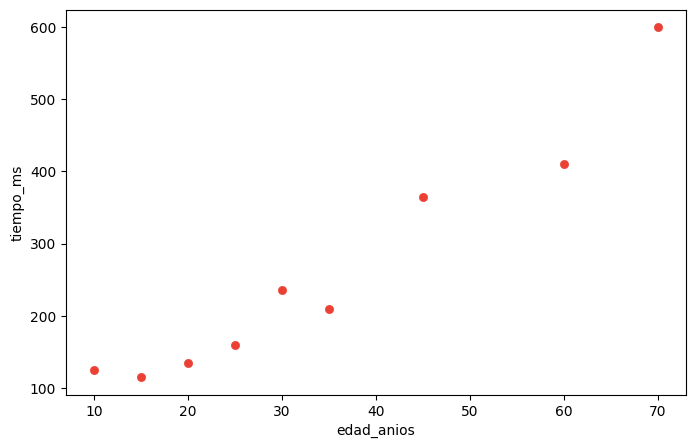

In [52]:
# Generamos el DataFrame con los datos
data_gamers = pd.DataFrame({
    'edad_anios': [10, 15, 20, 25, 30, 35, 45, 60, 70],
    'tiempo_ms':  [125, 115, 135, 160, 235, 210, 365, 410, 600]
})

# Representamos gráficamente los datos
plt.figure(figsize = (8,5))
sns.scatterplot(x = 'edad_anios', y = 'tiempo_ms', s = 35, color = '#eb4034', edgecolor = '#eb4034', data = data_gamers)
plt.show()

El gráfico de dispersión sugiere una relación positiva entre ambas variables: a mayor edad, mayor tiempo de reacción. Sin embargo, la relación no parece estrictamente lineal, lo que hace de Spearman una opción más apropiada que Pearson en este caso.

Para calcular $r_s$, primero se asignan rangos a cada variable. Como no hay empates, la asignación es directa:

| Edad (años) | Tiempo (ms) | Rango Edad | Rango Tiempo |
|:-----------:|:-----------:|:----------:|:------------:|
| 10          | 120         | 1          | 2            |
| 15          | 115         | 2          | 1            |
| 20          | 145         | 3          | 3            |
| 25          | 160         | 4          | 4            |
| 30          | 235         | 5          | 6            |
| 35          | 210         | 6          | 5            |
| 45          | 335         | 7          | 7            |
| 60          | 385         | 8          | 8            |

El coeficiente $r_s$ es entonces el coeficiente de Pearson calculado sobre estos rangos, es decir, sobre los datos representados en el siguiente gráfico:

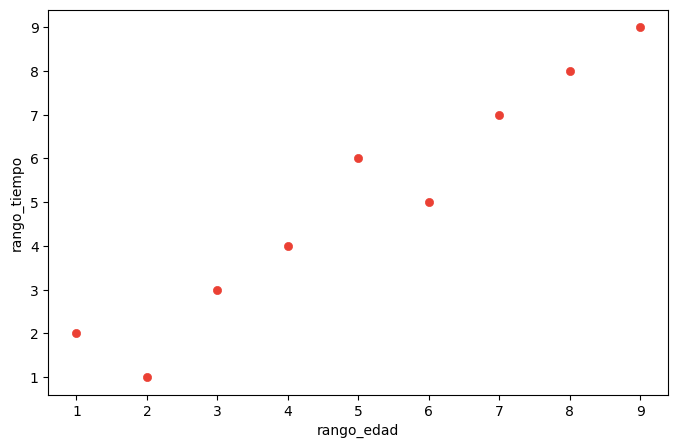

In [53]:
# Asignamos los rangos
data_gamers_ranks = pd.DataFrame({
    'rango_edad':   data_gamers['edad_anios'].rank(),
    'rango_tiempo': data_gamers['tiempo_ms'].rank()
})

# Representamos los rangos gráficamente
plt.figure(figsize = (8, 5))
sns.scatterplot(x = 'rango_edad', y = 'rango_tiempo', s = 35,
                color = '#eb4034', edgecolor = '#eb4034', data = data_gamers_ranks)
plt.show()

En la práctica, Pandas realiza este proceso internamente; basta con especificar `method = 'spearman'`:

In [54]:
data_gamers.corr(method = 'spearman')

,edad_anios,tiempo_ms
edad_anios,1.000000,0.966667
tiempo_ms,0.966667,1.000000


El valor obtenido es positivo y alto, lo que refleja una relación monótona creciente fuerte entre la edad y el tiempo de reacción, aunque no perfecta: hay algunas inversiones locales —como el leve descenso del tiempo de reacción entre los 10 y los 15 años, o entre los 30 y los 35— que impiden hablar de monotonicidad estricta. La relación es además claramente no lineal: el tiempo de reacción crece de forma marcadamente más pronunciada en las edades avanzadas, algo que el coeficiente de correlación de Pearson no capturaría adecuadamente.

## Matrices de covarianza y de correlación

Hasta ahora calculamos métricas de correlación para un único par de variables. Sin embargo, cuando el dataset contiene múltiples variables cuantitativas, resulta útil estudiar todas las relaciones posibles de forma simultánea. Para eso se construyen la **matriz de covarianza** y la **matriz de correlación**, que organizan estas métricas para todos los pares de variables.

En el dataset **penguins**, las variables cuantitativas son `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm` y `body_mass_g`. Trabajaremos exclusivamente con ellas.
La matriz de covarianza se obtiene con el método **`cov()`**:

In [55]:
df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].cov()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,29.807054,-2.534234,50.375765,2605.591912
bill_depth_mm,-2.534234,3.899808,-16.212950,-747.370093
flipper_length_mm,50.375765,-16.212950,197.731792,9824.416062
body_mass_g,2605.591912,-747.370093,9824.416062,643131.077327


El resultado es una matriz simétrica de 4×4 donde, como ya vimos, la diagonal contiene las varianzas de las observaciones de cada variable y los elementos fuera de la diagonal contienen las covarianzas entre cada par. Si bien esta matriz permite identificar la dirección de las relaciones, comparar sus valores entre distintos pares es difícil por las razones que discutimos al analizar las limitaciones de la covarianza.

Para resolver esto, recurrimos a la matriz de correlación de Pearson, que se obtiene con el método **`corr()`**:

In [56]:
df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].corr()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.235053,0.656181,0.595110
bill_depth_mm,-0.235053,1.000000,-0.583851,-0.471916
flipper_length_mm,0.656181,-0.583851,1.000000,0.871202
body_mass_g,0.595110,-0.471916,0.871202,1.000000


Esta matriz tiene la misma estructura, pero ahora todos los valores están acotados entre −1 y 1, lo que permite comparar directamente la intensidad de la asociación entre distintos pares de variables. La diagonal contiene unos, ya que cada variable está perfectamente correlacionada consigo misma.

### Correlograma

Cuando el número de variables crece, leer una matriz de números puede volverse tedioso. El correlograma es la representación gráfica de la matriz de correlación: un mapa de calor (*heatmap*) donde cada celda muestra el coeficiente de correlación entre un par de variables, y el color codifica su magnitud y dirección.

Para construirlo, generamos primero la matriz de correlación y luego la visualizamos con la función `heatmap()` de Seaborn. Algunos aspectos más finos de su construcción serán retomados en la próxima unidad:

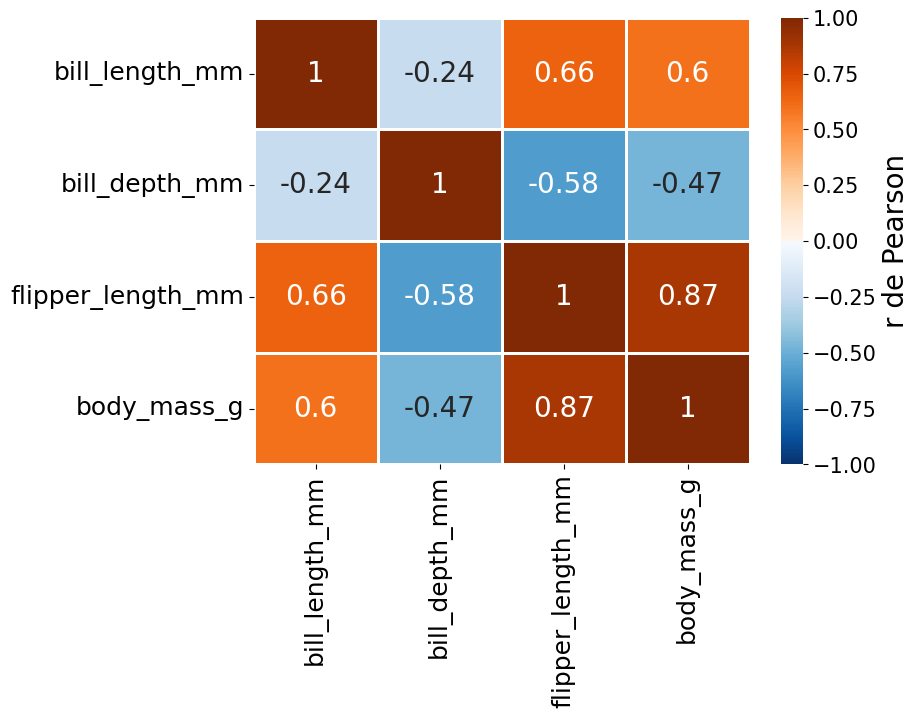

In [57]:
matriz = df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].corr()

palette_inferior = sns.color_palette('Oranges', 100)
palette_superior = sns.color_palette('Blues_r', 100)
colors = palette_superior + palette_inferior[::1]
cmap = sns.blend_palette(colors, as_cmap=True)

plt.figure(figsize=(8, 5.8))
ax = sns.heatmap(matriz, cmap=cmap, annot=True, linewidths=0.8,
                 annot_kws={"fontsize": 20},
                 cbar_kws={'label': 'r de Pearson'},
                 vmin=-1, vmax=1)
plt.xticks(fontsize=18, rotation=90)
plt.yticks(fontsize=18)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=15)
cbar.ax.yaxis.label.set_size(20)

plt.show()

El correlograma permite identificar de un vistazo qué pares de variables están fuertemente asociados, en qué dirección, y qué pares no presentan una relación lineal apreciable.

### Una advertencia: ¿nos puede engañar $r$?

Al observar el correlograma, el coeficiente de correlación de Pearson entre `bill_depth_mm` y `flipper_length_mm` es $r = -0.58$, lo que sugiere una asociación negativa moderada. Sin embargo, el *scatterplot* de este par revela algo inesperado:

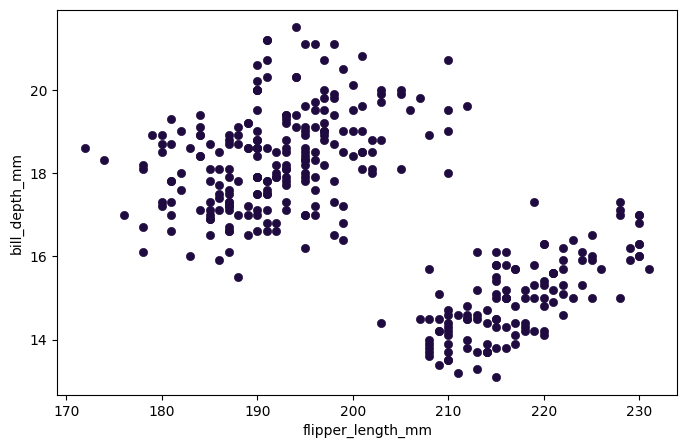

In [58]:
plt.figure(figsize = (8,5))

sns.scatterplot(x = 'flipper_length_mm', y = 'bill_depth_mm', data = df, s = 35, color = '#1f0b40', edgecolor = '#1f0b40')
plt.show()

Lo que se observa en el gráfico no es una nube de puntos con tendencia negativa uniforme, sino una estructura con subgrupos claramente diferenciados. Esto es un ejemplo concreto del principio que mencionamos anteriormente: **nunca interpretar un coeficiente de correlación sin haber observado previamente el gráfico de dispersión.**

En este caso, la causa es la variable `species`: cada especie presenta combinaciones distintas de profundidad de pico y longitud de aleta, y al calcular el coeficiente sobre el conjunto completo se mezclan patrones que en realidad pertenecen a grupos distintos. Este fenómeno, en el que una variable no considerada distorsiona la relación observada entre otras dos, se conoce como **paradoja de Simpson** y es uno de los errores más frecuentes en el análisis exploratorio de datos.

La solución es desagregar el análisis por grupos, lo que podemos hacer visualmente con el parámetro `hue`:

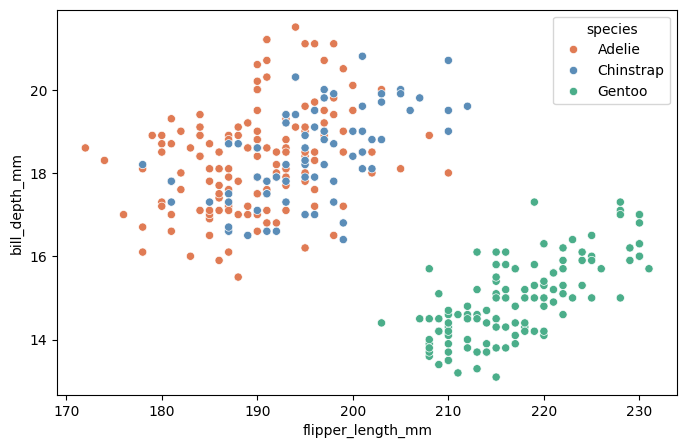

In [59]:
paleta_especies = {
    'Adelie':    '#E07B54',
    'Chinstrap': '#5B8DB8',
    'Gentoo':    '#4BAE8A'
}

plt.figure(figsize = (8, 5))
sns.scatterplot(x = 'flipper_length_mm', y = 'bill_depth_mm',
                hue = 'species', palette = paleta_especies,
                data = df, s = 35)
plt.show()

Al colorear los puntos por especie, la estructura del gráfico cambia radicalmente: dentro de cada especie, la relación entre ambas variables es positiva o prácticamente nula, lo que contradice la asociación negativa que habíamos obtenido para el conjunto completo. Esto refuerza una idea central del análisis exploratorio: **los coeficientes de correlación globales pueden ocultar patrones importantes que solo se revelan al segmentar los datos.** Retomaremos estas ideas en la próxima unidad.

## Temas avanzados

## Métricas de Distancia y Similaridad

Son métricas que nos a permiten definir cuánto se parecen dos puntos de datos, de forma similar a lo que vimos en la Unidad 2 con la similaridad de Levensthein on Jaro-Winkler. Existen diferentes formas de medir la similaridad y la selección de la misma depende del análisis que se esté realizando. A continuación listamos algunas de ellas.

### **Distancia Euclideana**

La definición formal es que la distancia euclideana es la distancia entre dos puntos en un [espacio euclídeo](https://es.wikipedia.org/wiki/Espacio_eucl%C3%ADdeo). La forma de visualizar esto es pensarlo como la distancia en linea recta entre dos puntos en el espacio. 

Si hablamos de un espacio de n dimensiones y queremos calcular la distancia entre los puntos P y Q, entonces:

$$
d_{E(P,Q)}= \sqrt{\sum_{i = 1}^{n}(p_i - q_i)^2}
$$

![Untitled](./imagenes/Untitled20.png)

**Desventajas**
Aunque es una medida de distancia común, la distancia euclidiana no es una escala invariante, lo que significa que las distancias calculadas pueden estar sesgadas según las unidades de las entidades. Por lo general, uno necesita normalizar los datos antes de usar esta medida de distancia.

Además, a medida que aumenta la dimensionalidad de sus datos, la distancia euclidiana se vuelve menos útil. 

**Casos de uso**
La distancia euclidiana funciona muy bien cuando tiene datos de baja dimensión y es importante medir la magnitud de los vectores. Métodos como [kNN](https://en.wikipedia.org/wiki/K-nearest_neighbors_algorithm) y [HDBSCAN](https://en.wikipedia.org/wiki/DBSCAN#Extensions) muestran excelentes resultados listos para usar si se usa la distancia euclidiana en datos de baja dimensión.

### **Distancia Manhattan**

La distancia de Manhattan se calcula como la suma de la diferencia absoluta entre los componentes de dos vectores P y Q 

$$
d_{M(P,Q)} = \sum_{i = 1}^{n}|p_i - q_i|
$$

La distancia de Manhattan es la norma L1 de un vector mientras que la euclideana es la norma L2. 

![Distancia Manhattan contra distancia Euclidiana: Las líneas roja, azul y amarilla tienen la misma longitud (12) en las geometrías Euclidiana y taxicab. En la geometría Euclidiana, la línea verde tiene longitud 6×√2 ≈ 8.48, y es el único camino más corto. En la geometría taxicab, la línea verde tiene longitud 12, por lo que no es más corta que los otros caminos.](./imagenes/Untitled21.png)

Distancia Manhattan contra distancia Euclidiana: Las líneas roja, azul y amarilla tienen la misma longitud (12) en las geometrías Euclidiana y taxicab. En la geometría Euclidiana, la línea verde tiene longitud 6×√2 ≈ 8.48, y es el único camino más corto. En la geometría taxicab, la línea verde tiene longitud 12, por lo que no es más corta que los otros caminos.

**Desventajas**
Aunque la distancia de Manhattan parece funcionar bien para datos de alta dimensión, es una medida algo menos intuitiva que la distancia euclidiana, especialmente cuando se usa en datos de alta dimensión.

Además, es más probable que proporcione un valor de distancia más alto que la distancia euclidiana, ya que no ofrece el camino más corto posible. Esto no necesariamente da problemas, pero es algo que debe tener en cuenta.

**Casos de uso**
Cuando su conjunto de datos tiene atributos discretos y/o binarios, Manhattan parece funcionar bastante bien, ya que tiene en cuenta las rutas que, de manera realista, podrían tomarse dentro de los valores de esos atributos. Tomar la distancia euclidiana, por ejemplo, crearía una línea recta entre dos vectores cuando en realidad esto podría no ser posible.

### **Similaridad de Coseno**

Mide el ángulo entre dos vectores en un espacio de varias dimensiones. Es una métrica popular para la comparación de documentos en procesamiento de lenguaje natural y sistemas de recomendación.

Sabemos que el producto punto entre dos vectores es igual al coseno del ángulo entre ellos por la longitud de los mismos

$$
u.v = cos(\theta) |u||v|
$$

Con esto se define la similitud coseno de la siguiente forma

$$
cos(\theta) = \frac{u.v}{|u||v|}
$$

Mirando la gráfica de la función coseno podemos decir que:

- Cuando $\theta$ es igual a 0, el coseno es igual a 1. En nuestro caso, los dos vectores coinciden perfectamente
- Cuando $\theta$ es igual a $\pi/2$ , el coseno es igual a 0. En nuestro caso, los dos vectores son ortogonales
- Cuando $\theta$ es igual a $\pi$, el coseno es igual a -1. En nuestro caso, los dos vectores se encuentran en posición diametralmente opuesta

![Untitled](./imagenes/Untitled22.png)

<aside>
💡 Notar que la magnitud de los vectores no entra en juego para esta similaridad

</aside>

![Untitled](./imagenes/Untitled23.png)

**Desventajas**
Una de las principales desventajas de la similitud del coseno es que no se tiene en cuenta la magnitud de los vectores, sino simplemente su dirección. En la práctica, esto significa que las diferencias de valores no se tienen plenamente en cuenta. Si toma un sistema de recomendación, por ejemplo, la similitud del coseno no tiene en cuenta la diferencia en la escala de calificación entre diferentes usuarios.

**Casos de uso**
Usamos la similitud del coseno a menudo cuando tenemos datos de alta dimensión y cuando la magnitud de los vectores no es importante. Para los análisis de texto, esta medida se utiliza con bastante frecuencia cuando los datos se representan mediante recuentos de palabras. Por ejemplo, cuando una palabra aparece con más frecuencia en un documento que en otro, esto no significa necesariamente que un documento esté más relacionado con esa palabra. Puede darse el caso de que los documentos tengan longitudes desiguales y la magnitud del conteo sea de menor importancia. Entonces, podemos usar mejor la similitud del coseno que no tiene en cuenta la magnitud.

### **Distancia de Mahalanobis**

En estadística, la distancia de Mahalanobis es una medida de distancia introducida por Mahalanobis en 1936. Su utilidad radica en que es una forma de determinar la similitud entre dos variables aleatorias multidimensionales. Se diferencia de la distancia euclídea en que tiene en cuenta la correlación entre las variables aleatorias.

![La distancia de Mahalanobis (MD) es una métrica de distancia efectiva que encuentra la distancia entre el punto y la distribución. Funciona con bastante eficacia en datos multivariados porque utiliza una matriz de covarianza de variables para encontrar la distancia entre los puntos de datos y el centro. Esto significa que MD detecta valores atípicos en función del patrón de distribución de los puntos de datos, a diferencia de la distancia euclidiana.](./imagenes/Untitled24.png)

La distancia de Mahalanobis (MD) es una métrica de distancia efectiva que encuentra la distancia entre el punto y la distribución. Funciona con bastante eficacia en datos multivariados porque utiliza una matriz de covarianza de variables para encontrar la distancia entre los puntos de datos y el centro. Esto significa que MD detecta valores atípicos en función del patrón de distribución de los puntos de datos, a diferencia de la distancia euclidiana.

En la siguientes figuras, el punto negro representa el centroide de la distribución. En la gráfica de la izquierda, tenemos una distribución no correlacionada. En ese caso, los valores atípicos serían los más alejados del centroide y se podría usar la distancia euclidiana para detectarlos. En el caso de la derecha, cuando las variables están correlacionadas, tiene más sentido usar Mahalanobis, ya que tiene en cuenta la correlación entre ambas variables. Allí el punto 2 sería un outlier, mientras que el punto 1 es parte de la distribución. 

![Untitled](./imagenes/Untitled25.png)

La distancia de Mahalanobis mide la distancia entre un punto P y el centroide de una distribución D y es igual a la distancia euclideana cuando las variables no están correlacionadas. 

Se define como:

$$
d_{M(x, \mu, D)} = \sqrt{(x - \mu)^T S^{-1}(x - \mu)}
$$

Y cuando nos interesa saber la distancia entre dos puntos, en vez de un punto y el centroide de los datos:

$$
d_{M(x,y, D)} = \sqrt{(x - y)^T S^{-1}(x - y)}
$$

Donde

$x, y$: puntos en el espacio

$\mu$: media de la distribución D

$S$: matriz de covarianza

Crearemos un conjunto de datos que muestre el puntaje del examen de 20 estudiantes junto con la cantidad de horas que dedicaron a estudiar, la cantidad de exámenes de preparación que tomaron y su calificación actual en el curso::

```python
import numpy as np
import pandas as pd 
import scipy as stats
from scipy.stats import chi2

data = {'score': [91, 93, 72, 87, 86, 73, 68, 87, 78, 99, 95, 76, 84, 96, 76, 80, 83, 84, 73, 74],
        'hours': [16, 6, 3, 1, 2, 3, 2, 5, 2, 5, 2, 3, 4, 3, 3, 3, 4, 3, 4, 4],
        'prep': [3, 4, 0, 3, 4, 0, 1, 2, 1, 2, 3, 3, 3, 2, 2, 2, 3, 3, 2, 2],
        'grade': [70, 88, 80, 83, 88, 84, 78, 94, 90, 93, 89, 82, 95, 94, 81, 93, 93, 90, 89, 89]
        }

df = pd.DataFrame(data,columns=['score', 'hours', 'prep','grade'])

# Crear función para calcular la distancia de Mahalanobis
def mahalanobis(x=None, data=None, cov=None):

    x_mu = x - np.mean(data)
    if not cov:
        cov = np.cov(data.values.T)
    inv_covmat = np.linalg.inv(cov)
    left = np.dot(x_mu, inv_covmat)
    mahal = np.dot(left, x_mu.T)
    return mahal.diagonal()

# Crea una nueva columna en el marco de datos que contiene 
# la distancia de Mahalanobis para cada fila
df['mahalanobis'] = mahalanobis(x=df, data=df[['score', 'hours', 'prep', 'grade']])

# Calcular el valor p para cada distancia mahalanobis
df['p'] = 1 - chi2.cdf(df['mahalanobis'], 3)

# Mostrar valores p para las primeras cinco filas en el marco de datos
df.head()

"""
  score	hours	prep	grade	mahalanobis	p
0	91	16	3	70	16.501963	0.000895
1	93	6	4	88	2.639286	0.450644
2	72	3	0	80	4.850797	0.183054
3	87	1	3	83	5.201261	0.157639
4	86	2	4	88	3.828734	0.280562
"""
```

La interpretación de los valores p es la siguiente:

- Un valor p cercano a 1 indica que la probabilidad de que la observación sea un valor típico dentro de la distribución es alta, por lo que no se considera un valor atípico.
- Un valor p cercano a 0 indica que la probabilidad de que la observación sea un valor típico dentro de la distribución es baja, lo que sugiere que podría ser un valor atípico. Generalmente, se considera que una observación con un valor p inferior a 0.001 es un valor atípico. En este ejemplo, vemos un valor atípico en el primer registro.

**Desventajas**

Suposición de normalidad: La distancia de Mahalanobis supone que los datos siguen una distribución normal multivariante. Si esta suposición no se cumple, la distancia de Mahalanobis podría no ser apropiada o requeriría ajustes en la metodología.

Sensibilidad a la matriz de covarianza: La distancia de Mahalanobis depende de la matriz de covarianza, y el cálculo de su inversa puede ser numéricamente inestable en algunos casos. Esto puede ser un problema en conjuntos de datos de alta dimensionalidad o cuando hay multicolinealidad (variables altamente correlacionadas).

No apropiada para distribuciones no lineales: La distancia de Mahalanobis no es adecuada para conjuntos de datos con relaciones no lineales entre las variables, ya que solo considera las correlaciones lineales.

**Casos de uso**

Detección de valores atípicos: La distancia de Mahalanobis es útil para identificar valores atípicos en un conjunto de datos multivariante, ya que considera la correlación entre las variables y la variabilidad de cada variable. Los puntos con distancias de Mahalanobis grandes pueden ser considerados como valores atípicos.

Clasificación y reconocimiento de patrones: La distancia de Mahalanobis puede utilizarse en problemas de clasificación y reconocimiento de patrones, donde se intenta asignar un objeto desconocido a una de varias clases predefinidas. La distancia de Mahalanobis puede ser utilizada como métrica de similitud para determinar la cercanía entre un objeto desconocido y los objetos en cada clase.

Análisis de conglomerados (clustering): La distancia de Mahalanobis puede ser utilizada en algoritmos de clustering para medir la similitud entre puntos en un espacio multivariante. Algoritmos como K-means o agrupamiento jerárquico pueden utilizar la distancia de Mahalanobis en lugar de la distancia euclidiana para tener en cuenta la correlación entre variables y la variabilidad de cada variable.

### **Distancia de Jaccard**

El coeficiente de similitud de Jaccard o índice de Jaccard mide la similitud entre dos conjuntos de muestras y fue concebido con la intención de comparar los tipos de flores presentes en un ecosistema de la cuenca de un río, con los tipos presentes en las regiones aledañas. Se define como la relación entre el tamaño de la intersección de ambos conjuntos y el tamaño de la unión:

$$
sim_{J(A,B)} = \frac{|A\cap B|}{|A \cup B|}
$$

La *distancia de Jaccard* mide la disimilitud entre dos conjuntos de muestras y se define como el complemento del coeficiente de Jaccard:

$$
J (A,B) = 1 - sim_{J(A,B)}
$$

El coeficiente de Jaccard toma valores entre 0 y 1, siendo 1 la coincidencia perfecta entre ambos conjuntos, cuando la intersección es igual a la unión

Esta distancia puede utilizarse en análisis de texto: La distancia de Jaccard se utiliza para comparar documentos o textos en función de la similitud entre sus conjuntos de palabras, caracteres o n-gramas, o puede ser útil también en sistemas de recomendación, para medir la similitud entre usuarios o elementos en función de los conjuntos de características, preferencias o comportamientos de los usuarios.

**Desventajas**

La distancia de Jaccard puede verse afectada por diferencias significativas en el tamaño de los conjuntos que se comparan. Por ejemplo, si un conjunto es mucho más grande que otro, la distancia de Jaccard puede ser alta incluso si hay una superposición considerable entre los conjuntos.

No apta para datos numéricos continuos: La distancia de Jaccard está diseñada para comparar conjuntos y, por lo tanto, no es adecuada para trabajar con datos numéricos continuos. Para datos continuos, es necesario utilizar otras medidas de distancia, como la distancia euclidiana o la distancia de Mahalanobis.

No considera la estructura interna de los datos: La distancia de Jaccard solo tiene en cuenta la presencia o ausencia de elementos en los conjuntos, pero no considera la estructura interna o las relaciones entre los elementos dentro de los conjuntos. En situaciones donde la estructura interna de los datos es importante, podrían ser más adecuadas otras medidas de similitud o técnicas de análisis.

Sensibilidad a la presencia de elementos irrelevantes: La distancia de Jaccard puede verse afectada por la presencia de elementos irrelevantes o ruidosos en los conjuntos. Estos elementos pueden aumentar la distancia de Jaccard entre dos conjuntos que, de lo contrario, serían muy similares.

**Casos de uso**

La distancia de Jaccard se utiliza a menudo en el análisis de texto para comparar la similitud entre documentos. Por ejemplo, se pueden comparar documentos en función de las palabras o términos que contienen, y luego agruparlos o clasificarlos según su similitud.

Comparación de comunidades biológicas: En ecología y biología, la distancia de Jaccard se utiliza a menudo para comparar la similitud entre comunidades biológicas, como la presencia de especies en diferentes hábitats o ecosistemas. También se puede aplicar en el análisis de datos genéticos para comparar la similitud entre diferentes genomas, especialmente en el contexto de datos de secuenciación de ADN.

Sistemas de recomendación: La distancia de Jaccard puede ser útil en sistemas de recomendación para medir la similitud entre usuarios o elementos en función de sus características binarias o categóricas. Por ejemplo, se puede utilizar para comparar la similitud entre usuarios en función de las películas que han visto o los productos que han comprado. También en el análisis de redes sociales, la distancia de Jaccard se utiliza a menudo para comparar la similitud entre los miembros de una red en función de sus conexiones o intereses compartidos.

### **Distancias entre palabras**

Pueden consultar a la unidad 2 donde estudiamos distancia de Levensthein y de Jaro-Winkler

[**KPI Estándares**](https://www.notion.so/KPI-Est-ndares-86f5927d6c7745b2ae7fdee69d4decee?pvs=21)